# Analyses of the NEMO's outputs (main analyses)

This notebook contains all the analyses of the NEMO's outputs of Fiol et al. "Ice shelf basal melting in giant proglacial lakes". Analyses present in this notebook: basal melt rates (except those on parameterisation), buoyancy fluxes, overturning circulation, and T-S diagram. 

In [1]:
#import the libraries needed
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np
import xarray as xr
from cmocean import cm as cmo

### Name of the experiments and where to find them 

In [2]:
#define some names and paths to find the experiments
chemin="/ccc/work/cont003/gen6035/fiollaur/models/my_isomip/tests/" #path to where the NEMO's configuration is
config="config_article/" #NEMO's configuration
nom_fichierT="ISOMIP+_1m_grid_T.nc" #name of the file with outputs at T-point
nom_fichierU="ISOMIP+_1m_grid_U.nc" #name of the file with outputs at U-point

In [3]:
#lists of the different restoring salinities and temperatures of the experiments
liste_salinite=["0_001","0_3","0_6","0_9"]
liste_temperature=["0_1","1","1-2","1-3","3","6","6-4","8","8-4","8-6","10","10-6","10-8"]

In [4]:
#reconstruct the name of the experiments
nom_experiences=[]
for sal in liste_salinite:
    for temp in liste_temperature:
        nom_exp="S"+sal+"_T"+temp
        nom_experiences.append(nom_exp)
        #print("exp_"+nom_exp+"/"+nom_fichierT)

In [5]:
#some checks
nbre_experiences=len(nom_experiences)
nbre_salin_diff=len(liste_salinite)
nbre_temp_diff=len(liste_temperature)
print(nbre_experiences)
print(nbre_salin_diff)
print(nbre_temp_diff)
print(nom_experiences)

52
4
13
['S0_001_T0_1', 'S0_001_T1', 'S0_001_T1-2', 'S0_001_T1-3', 'S0_001_T3', 'S0_001_T6', 'S0_001_T6-4', 'S0_001_T8', 'S0_001_T8-4', 'S0_001_T8-6', 'S0_001_T10', 'S0_001_T10-6', 'S0_001_T10-8', 'S0_3_T0_1', 'S0_3_T1', 'S0_3_T1-2', 'S0_3_T1-3', 'S0_3_T3', 'S0_3_T6', 'S0_3_T6-4', 'S0_3_T8', 'S0_3_T8-4', 'S0_3_T8-6', 'S0_3_T10', 'S0_3_T10-6', 'S0_3_T10-8', 'S0_6_T0_1', 'S0_6_T1', 'S0_6_T1-2', 'S0_6_T1-3', 'S0_6_T3', 'S0_6_T6', 'S0_6_T6-4', 'S0_6_T8', 'S0_6_T8-4', 'S0_6_T8-6', 'S0_6_T10', 'S0_6_T10-6', 'S0_6_T10-8', 'S0_9_T0_1', 'S0_9_T1', 'S0_9_T1-2', 'S0_9_T1-3', 'S0_9_T3', 'S0_9_T6', 'S0_9_T6-4', 'S0_9_T8', 'S0_9_T8-4', 'S0_9_T8-6', 'S0_9_T10', 'S0_9_T10-6', 'S0_9_T10-8']


In [6]:
#markers and linestyles associated to the experiments
marker_style_experiences=["^" for m in range(nbre_temp_diff)]+["p" for m in range(nbre_temp_diff)]+["D" for m in range(nbre_temp_diff)]+["s" for m in range(nbre_temp_diff)]
marker_size_experiences=[55 for m in range(nbre_temp_diff)]+[60 for m in range(nbre_temp_diff)]+[35 for m in range(nbre_temp_diff)]+[35 for m in range(nbre_temp_diff)]
ligne_style_experiences=["-" for m in range(nbre_temp_diff)]+["--" for m in range(nbre_temp_diff)]+["-." for m in range(nbre_temp_diff)]+["dotted" for m in range(nbre_temp_diff)]
print(marker_style_experiences)
print(marker_size_experiences)
print(ligne_style_experiences)

['^', '^', '^', '^', '^', '^', '^', '^', '^', '^', '^', '^', '^', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 's', 's', 's', 's', 's', 's', 's', 's', 's', 's', 's', 's', 's']
[55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35]
['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '--', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', '-.', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted', 'dotted']


In [7]:
#colors associated to the experiments
couleurs_experiences=["dimgrey","#040273","blue","cornflowerblue","lightskyblue","yellow","turquoise","#FC5A50","#FCE166","orange","black","#E50000","darkred"]

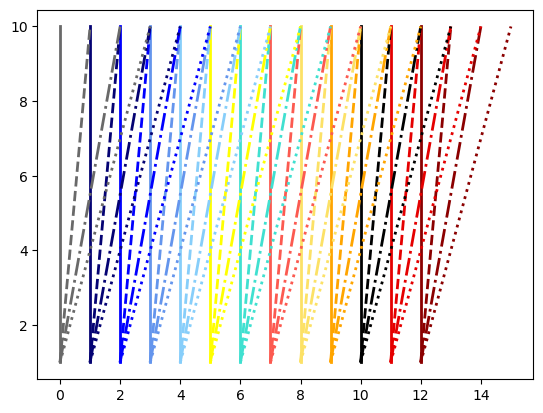

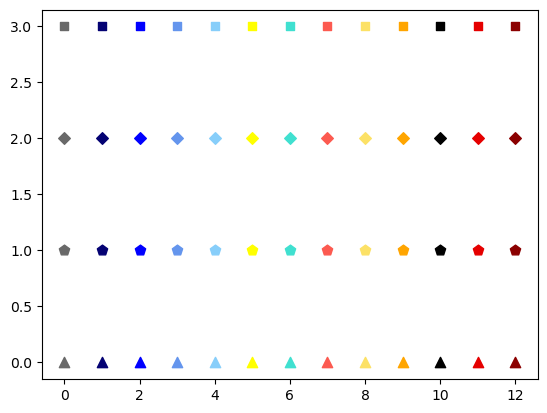

In [8]:
#some visualisation
for l in range(nbre_experiences):
    plt.plot(np.linspace(l%nbre_temp_diff,l%nbre_temp_diff+l//nbre_temp_diff,10),np.linspace(1,10,10),linestyle=ligne_style_experiences[l],color=couleurs_experiences[l%nbre_temp_diff],lw=2)
plt.show()
    
for l in range(nbre_experiences):
    plt.scatter(l%nbre_temp_diff,l//nbre_temp_diff,marker=marker_style_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],s=marker_size_experiences[l])
plt.show()

In [9]:
#loading the domain
data_domain=xr.open_dataset(chemin+config+"SETTE/domain_f58N_pen01_smo4_h2km_z20m.nc")

### Define functions, masks and variables needed for the analyses

**functions**

In [10]:
def alphaSEOS(SA,CT,z,a0,lambda1,mu1,nu):
    """
    Calculate the thermal expansion coefficient alpha.
    
    Alpha is calculated using the simplified equation of state presented in Fiol et al. "Ice shelf basal melting in giant proglacial lakes".

    Parameters
    ----------
    SA : Absolute Salinity (g/kg)
    CT : Conservative Temperature (°C)
    z : depth (m) (equal to zero at the surface and positive towards depth)
    a0, lambda1, mu1, nu : some coefficients

    Returns
    -------
    alpha : thermal expansion coefficient (1/°C)
    """  
    
    global rho0,S0,T0 #reference density, reference salinity, reference temperature
    #print("rho0",rho0,"S0",S0,"T0",T0)
    #print("a0",a0,"lambda1",lambda1,"mu1",mu1,"nu",nu)
    
    Sanom=SA-S0 #salinity anomaly
    Tanom=CT-T0 #temperature anomaly

    #computation
    alpha=(1/rho0)*(a0*(1+lambda1*Tanom+mu1*z)+nu*Sanom)
    return alpha

In [11]:
def betaSEOS(SA,CT,z,b0,lambda2,mu2,nu):
    """
    Calculate the saline contraction coefficient beta.
    
    Beta is calculated using the simplified equation of state presented in Fiol et al. "Ice shelf basal melting in giant proglacial lakes".

    Parameters
    ----------
    SA : Absolute Salinity (g/kg)
    CT : Conservative Temperature (°C)
    z : depth (m) (equal to zero at the surface and positive towards depth)
    b0, lambda2, mu2, nu : some coefficients

    Returns
    -------
    beta : saline contraction coefficient (1/(g/kg))
    """    
    
    global rho0,S0,T0 #reference density, reference salinity, reference temperature
    #print("rho0",rho0,"S0",S0,"T0",T0)
    #print("b0",b0,"lambda2",lambda2,"mu2",mu2,"nu",nu)
    
    Sanom=SA-S0 #salinity anomaly
    Tanom=CT-T0 #temperature anomaly

    #computation
    beta=(1/rho0)*(b0*(1-lambda2*Sanom-mu2*z)-nu*Tanom)
    return beta

In [12]:
def overturning(vitesse,e3u,e2u,mask):
    """
    Calculate the overturning.
    
    Parameters
    ----------
    vitesse : water velocities along the x-axis (m/s)
    e3u : water depth between two grid cells with the same coordinates x and y (m) 
        minimum 2 m, maximum 20 m if not in the penalised part, between 2 and 20 m in the penalised part
    /!\ vitesse and e3u should have the same dimensions in the same order!
    
    e2u : y spatial resolution (m) 
    mask : mask equals 0 when there is no water within the cell and 1 otherwise

    Returns
    -------
    overturning in Sv (1 Sv = 10**6 m3/s)
    """
    
    calcul_preli=vitesse*e3u*e2u*mask[0,:,:,:] #preliminary computation
    
    #Sum on y-dimension
    
    IDy=calcul_preli.get_axis_num("y")
    
    S=-calcul_preli.sum(axis=IDy)
    
    
    #Cumulative sum from the floor to the surface
    IDz=S.get_axis_num("depthu")

    overturn=S[:,::-1,:].cumsum(axis=IDz)[:,::-1,:]
    
    return overturn/(1.0e6)

In [13]:
def fexponent(num):
    """""
    This function returns the exponent corresponding to the order of magnitude of the number.
    """""
    if num<0:
        return int(np.floor(np.log10(-num)))
    elif num==0:
        return 0
    else:
        return int(np.floor(np.log10(num)))

**useful variables**

In [14]:
#variables associated to the equation of state
rhofw=1000.0 ; rho0=1000.38 ; S0=0.5 ; T0=4.0 #density of fresh water, reference density, reference salinity, reference temperature
print(rhofw,rho0,S0,T0)
coefs=[-2.274e-03,8.0228e-01,-6.121,1.3726e-02,3.3176e-03,-1.279e-02,1.135e-05] #coefficients of the simplified equation of state
print(coefs[0],coefs[1],coefs[2],coefs[3],coefs[4],coefs[5],coefs[6])
coefs_alpha=[-2.274e-03,-6.121,-1.279e-02,3.3176e-03] #coefficients to compute alpha
print(coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])
coefs_beta=[8.0228e-01,1.3726e-02,1.135e-05,3.3176e-03] #coefficients to compute beta
print(coefs_beta[0],coefs_beta[1],coefs_beta[2],coefs_beta[3])

1000.0 1000.38 0.5 4.0
-0.002274 0.80228 -6.121 0.013726 0.0033176 -0.01279 1.135e-05
-0.002274 -6.121 -0.01279 0.0033176
0.80228 0.013726 1.135e-05 0.0033176


In [15]:
#time variables
conv_invs_invan=365.*24.*3600. #conversion coef
nbre_j_an=365 #number of days within a year
nbre_mois_an=12 #number of months within a year
fq_output=1 #output frequency in months
nbre_annee_total=15 #total number of simulated year
annee_deb_voulue=12 #first year to consider in the analyses
nbre_annee_voulue=4 #number of years to consider in the analyses
debmoy_yr=int((annee_deb_voulue-1)*(nbre_mois_an/fq_output)) #first time index to consider in the analyses
finmoy_yr=int(debmoy_yr+nbre_annee_voulue*nbre_mois_an/fq_output-1) #last time index to consider in the analyses
print(debmoy_yr,finmoy_yr)
size_time=int(nbre_annee_total*nbre_mois_an/fq_output) #size of time in the outputs
print(size_time)
print("number of time step considered: ",finmoy_yr-debmoy_yr+1)

132 179
180
number of time step considered:  48


In [16]:
#variables linked to spatial dimensions of the domain
size_z=data_domain.sizes['nav_lev']
size_x=data_domain.sizes['x']
size_y=data_domain.sizes['y']
print("z",size_z,"x",size_x,"y",size_y)
print(data_domain.e2u[0,:,:].mean(axis=(0,1)).values)
e2u=2000.0 #2 km

z 37 x 242 y 42
2000.0


In [17]:
#some other variables
L= 0.334e6 #latent heat of fusion of ice (J/kg)
cp= 4204.5837 #isobaric specific heat capacity of water (J/(kg*K))
g=9.80665 #gravity parameter (m/s2)
print(L,cp,g)

334000.0 4204.5837 9.80665


In [18]:
#coefficients of the linear freezing temperature
l_1=-0.0572;l_2=0.0197;l_3=-7.5519e-04
print(l_1,l_2,l_3)

-0.0572 0.0197 -0.00075519


**masks**

In [19]:
#loading the file containing the masks
data_mask=xr.open_dataset(chemin+config+"exp_mask/mesh_mask.nc")

In [20]:
#change the name of depth for outputs at T- and U-points
data_maskT=data_mask.rename({'nav_lev':'deptht'})
data_maskU=data_mask.rename({'nav_lev':'depthu'})
print(data_maskT)
print(data_maskU)
data_mask.close()

<xarray.Dataset>
Dimensions:       (y: 42, x: 242, deptht: 37, time_counter: 1)
Coordinates:
  * deptht        (deptht) float32 10.0 30.0 50.0 70.0 ... 690.0 710.0 730.0
  * time_counter  (time_counter) float32 0.0
Dimensions without coordinates: y, x
Data variables: (12/37)
    nav_lon       (y, x) float32 ...
    nav_lat       (y, x) float32 ...
    tmask         (time_counter, deptht, y, x) int8 ...
    umask         (time_counter, deptht, y, x) int8 ...
    vmask         (time_counter, deptht, y, x) int8 ...
    fmask         (time_counter, deptht, y, x) int8 ...
    ...            ...
    gdept_1d      (time_counter, deptht) float64 ...
    gdepw_1d      (time_counter, deptht) float64 ...
    e3t_0         (time_counter, deptht, y, x) float64 ...
    e3u_0         (time_counter, deptht, y, x) float64 ...
    e3v_0         (time_counter, deptht, y, x) float64 ...
    e3f_0         (time_counter, deptht, y, x) float64 ...
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    

In [21]:
#ice-shelf mask from "top_level" and "rpi" variables of the domain file

shelf=(data_domain.rpi[0,:,:].where(data_domain.rpi[0,:,:]>0)).where(data_domain.top_level[0,:,:]>0) #ice field (rpi>0) + at least one cell with water (top_level>0)
shelf_norm=shelf/shelf #mask with only NaN and ones
shelf_norm0=shelf_norm.fillna(0) #mask with only zeros and ones

In [22]:
#some x-positions useful for the analyses
field_xpos=np.ones((size_y,size_x))*np.nan
for ypos in data_domain.y.values:
    field_xpos[ypos,:]=data_domain.x.values
print(np.nanmax(field_xpos*shelf_norm,axis=1)) 
print(np.nanmin(field_xpos*shelf_norm,axis=1)) 

xpos_front=164 #position of the front
xpos_dvtfront=164+1 #position before the front
xpos_gl=68 #position of the deepest grounding line

[ nan 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.
 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.
 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.  nan]
[nan 96. 96. 95. 95. 94. 83. 75. 72. 71. 70. 70. 69. 69. 69. 68. 68. 68.
 68. 68. 68. 68. 68. 68. 68. 68. 68. 69. 69. 69. 70. 70. 71. 72. 75. 83.
 95. 95. 95. 95. 96. nan]


/tmp/ipykernel_3166684/465214030.py:5: RuntimeWarning: All-NaN axis encountered
  print(np.nanmax(field_xpos*shelf_norm,axis=1))
/tmp/ipykernel_3166684/465214030.py:6: RuntimeWarning: All-NaN axis encountered
  print(np.nanmin(field_xpos*shelf_norm,axis=1))


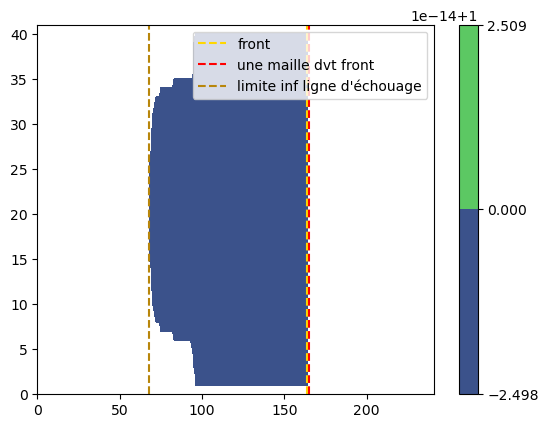

In [23]:
#some visualisation
plt.contourf(shelf_norm)
plt.plot(np.linspace(xpos_front,xpos_front,size_y),np.linspace(0,size_y-1,size_y), linestyle="--",color="gold",label="front")
plt.plot(np.linspace(xpos_dvtfront,xpos_dvtfront,size_y),np.linspace(0,size_y-1,size_y),linestyle="--",color="red",label="une maille dvt front")
plt.plot(np.linspace(xpos_gl,xpos_gl,size_y),np.linspace(0,size_y-1,size_y), linestyle="--",color="darkgoldenrod",label="limite inf ligne d'échouage")
plt.legend(loc="upper right")
plt.colorbar()
plt.show()

2


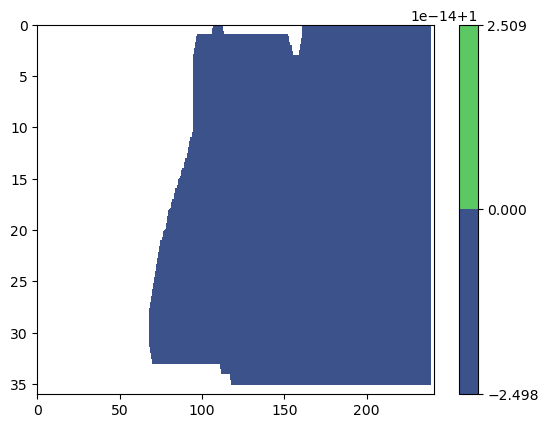

In [24]:
#mask used for the overturning figure
#mask equals 1 (for a given x and zero) if there is at least one y-position with a cell with water; otherwise, it equals NaN 
print((data_maskU.umask.where(data_maskU.umask>0)).get_axis_num("y"))
mask_shelf_calcul_zx=(data_maskU.umask.where(data_maskU.umask>0)).mean(axis=2)[0,:,:]

plt.contourf(mask_shelf_calcul_zx)
plt.colorbar()
plt.ylim(36,0)
plt.show()

## Compute variables of interest

**computation**

In [25]:
#melt
fonte=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    fonte.append(conv_invs_invan*(exp.sowflisf[debmoy_yr:finmoy_yr+1,:,:]*shelf_norm0)/rhofw)
    exp.close()

In [26]:
print(len(fonte)==nbre_experiences)

True


In [27]:
#circulation
OVT=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierU)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierU)
    OVT.append(overturning(exp.vozocrtx[debmoy_yr:finmoy_yr+1,:,:,:],exp.e3u[debmoy_yr:finmoy_yr+1,:,:,:],e2u,data_maskU.umask))
    exp.close()

In [28]:
print(len(OVT)==nbre_experiences)

True


In [29]:
#alpha and beta
alpha=[] ; beta=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    alpha.append(alphaSEOS(exp.vosaline[debmoy_yr:finmoy_yr+1,:,:,:],exp.votemper[debmoy_yr:finmoy_yr+1,:,:,:],exp.deptht,coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3]))
    beta.append(betaSEOS(exp.vosaline[debmoy_yr:finmoy_yr+1,:,:,:],exp.votemper[debmoy_yr:finmoy_yr+1,:,:,:],exp.deptht,coefs_beta[0],coefs_beta[1],coefs_beta[2],coefs_beta[3]))
    exp.close()

In [30]:
print(len(alpha)==nbre_experiences)
print(len(beta)==nbre_experiences)

True
True


In [31]:
#buoyancy fluxes
Ftherm=[] ; Fsaline=[] ; Fflot=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    Ftherm.append((-g*L/cp)*alpha[l]*exp.sowflisf_3d[debmoy_yr:finmoy_yr+1,:,:,:]*data_maskT.tmask[0,:,:,:])
    Fsaline.append(g*beta[l]*exp.vosaline[debmoy_yr:finmoy_yr+1,:,:,:]*exp.sowflisf_3d[debmoy_yr:finmoy_yr+1,:,:,:]*data_maskT.tmask[0,:,:,:])
    Fflot.append(Ftherm[l]+Fsaline[l])
    exp.close()

In [32]:
print(len(Ftherm)==nbre_experiences)
print(len(Fsaline)==nbre_experiences)
print(len(Fflot)==nbre_experiences)

True
True
True


In [33]:
#2D buoyancy fluxes
Ftherm_map=[] ; Fsaline_map=[] ; Fflot_map=[]
for l in range(nbre_experiences):
    IDzF=1
    print(Ftherm[l].get_axis_num("deptht"))
    print(Fsaline[l].get_axis_num("deptht"))
    print(Fflot[l].get_axis_num("deptht"))
    Ftherm_map.append(Ftherm[l].sum(axis=IDzF))
    Fsaline_map.append(Fsaline[l].sum(axis=IDzF))
    Fflot_map.append(Fflot[l].sum(axis=IDzF))

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [34]:
print(len(Ftherm_map)==nbre_experiences)
print(len(Fsaline_map)==nbre_experiences)
print(len(Fflot_map)==nbre_experiences)

True
True
True


**temporal mean**

In [35]:
fonte_yrmoy=[]; OVT_yrmoy=[]; Fflot_yrmoy=[]; Ftherm_yrmoy=[]; Fsaline_yrmoy=[]
for l in range(nbre_experiences):
    ID_t=0
    fonte_yrmoy.append(fonte[l].mean(axis=ID_t))
    OVT_yrmoy.append(OVT[l].mean(axis=ID_t))
    Fflot_yrmoy.append(Fflot_map[l].mean(axis=ID_t))
    Ftherm_yrmoy.append(Ftherm_map[l].mean(axis=ID_t))
    Fsaline_yrmoy.append(Fsaline_map[l].mean(axis=ID_t))

In [36]:
print(len(fonte_yrmoy)==nbre_experiences)
print(len(OVT_yrmoy)==nbre_experiences)
print(len(Fflot_yrmoy)==nbre_experiences)
print(len(Ftherm_yrmoy)==nbre_experiences)
print(len(Fsaline_yrmoy)==nbre_experiences)

True
True
True
True
True


## Grouping

In [37]:
#compute the limit of the front before entering the penalised part
#from the penalised limit, we look at which position melting is not equal to zero anymore

for l in range(nbre_experiences):
    cpt_minus=0
    while fonte_yrmoy[l][:,xpos_front-cpt_minus].sum(axis=0).values == 0:
        cpt_minus+=1
    print(xpos_front-cpt_minus)
    
xpos_frontr=161
print("//",xpos_frontr)

161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
161
// 161


**automatical grouping**

In [38]:
Group0=[];GroupI=[];GroupII=[];GroupIII=[] #will contain the indexes of their experiments

nbre_val_max=10;critere_nbre_km=50 #some criteria

liste_moy_fonteGL=[] #list of the mean melt rates close to the grounding line
liste_moy_fontefront=[] #list of the mean melt rates close to the front

#will contains ranges of the mean melt rates close to the grounding line and close to the front
range_fonte_moy_gl_num=[[999.,-999.],[999.,-999.],[999.,-999.],[999.,-999.]]
range_fonte_moy_front_num=[[999.,-999.],[999.,-999.],[999.,-999.],[999.,-999.]]

#some computations and grouping
for l in range(nbre_experiences):
    print(nom_experiences[l])
    
    #percentage of cells with refreezing
    pourcentage_refreez=100*(((fonte_yrmoy[l].where(fonte_yrmoy[l]<0)/fonte_yrmoy[l]).fillna(0)).sum(axis=(0,1))/shelf_norm0.sum(axis=(0,1)))
    #print("% refreez",pourcentage_refreez.values)
    
    #position of the n maximal values of the mean melt rate along the y-axis
    fonte_yrmoy_ymoy=fonte_yrmoy[l].sum(axis=0)/shelf_norm0.sum(axis=0) #mean melt rate along the y-axis
    #print(l,nom_experiences[l],fonte_yrmoy_ymoy.values)
    
        #position of the n maximal values
    liste_pos_temp=[]
    while len(liste_pos_temp)!=nbre_val_max:
        pos_temp=fonte_yrmoy_ymoy.argmax(axis=0).values
        liste_pos_temp.append(pos_temp)
        fonte_yrmoy_ymoy[pos_temp]=-999.
    #print("pos max",liste_pos_temp)

    #print("problem if not 0:",np.sum(np.array(liste_pos_temp)<xpos_gl))
    #print("problem if not 0:",np.sum(np.array(liste_pos_temp)>xpos_frontr))
    
    #compute the mean melt rate close to the grounding line and close to the front
    moy_fonteGL=fonte_yrmoy[l][:,xpos_gl:xpos_gl+critere_nbre_km//2+1].sum(axis=(0,1))/shelf_norm0[:,xpos_gl:xpos_gl+critere_nbre_km//2+1].sum(axis=(0,1))
    print(nom_experiences[l],"proche GL",moy_fonteGL.values)
    moy_fontefront=fonte_yrmoy[l][:,xpos_frontr-critere_nbre_km//2-1:xpos_frontr].sum(axis=(0,1))/shelf_norm0[:,xpos_frontr-critere_nbre_km//2-1:xpos_frontr].sum(axis=(0,1))
    print(nom_experiences[l],"proche front",moy_fontefront.values)
    
    liste_moy_fonteGL.append(moy_fonteGL)
    liste_moy_fontefront.append(moy_fontefront)
    
    #Grouping
        #Group0
    if pourcentage_refreez>=20: 
        print(pourcentage_refreez.values,"%",nom_experiences[l]," : Group0")
        Group0.append(l)

        #compute ranges GL and front
        if moy_fonteGL<range_fonte_moy_gl_num[0][0]:
            range_fonte_moy_gl_num[0][0]=moy_fonteGL.values
        if moy_fonteGL>range_fonte_moy_gl_num[0][1]:
            range_fonte_moy_gl_num[0][1]=moy_fonteGL.values
        if moy_fontefront<range_fonte_moy_front_num[0][0]:
            range_fonte_moy_front_num[0][0]=moy_fontefront.values
        if moy_fontefront>range_fonte_moy_front_num[0][1]:
            range_fonte_moy_front_num[0][1]=moy_fontefront.values
    
        #GroupI
    if (pourcentage_refreez<20) and (np.sum(np.array(liste_pos_temp)<=xpos_gl+critere_nbre_km//2)>=nbre_val_max-2):
        print(nom_experiences[l]," : Groupe I")
        GroupI.append(l)

        #compute ranges GL and front
        if moy_fonteGL<range_fonte_moy_gl_num[1][0]:
            range_fonte_moy_gl_num[1][0]=moy_fonteGL.values
        if moy_fonteGL>range_fonte_moy_gl_num[1][1]:
            range_fonte_moy_gl_num[1][1]=moy_fonteGL.values
        if moy_fontefront<range_fonte_moy_front_num[1][0]:
            range_fonte_moy_front_num[1][0]=moy_fontefront.values
        if moy_fontefront>range_fonte_moy_front_num[1][1]:
            range_fonte_moy_front_num[1][1]=moy_fontefront.values

        #GroupIII
    if (pourcentage_refreez<20) and (moy_fontefront>=4*moy_fonteGL):
        print(nom_experiences[l]," : Groupe III")
        GroupIII.append(l)

        #compute ranges GL and front
        if moy_fonteGL<range_fonte_moy_gl_num[3][0]:
            range_fonte_moy_gl_num[3][0]=moy_fonteGL.values
        if moy_fonteGL>range_fonte_moy_gl_num[3][1]:
            range_fonte_moy_gl_num[3][1]=moy_fonteGL.values
        if moy_fontefront<range_fonte_moy_front_num[3][0]:
            range_fonte_moy_front_num[3][0]=moy_fontefront.values
        if moy_fontefront>range_fonte_moy_front_num[3][1]:
            range_fonte_moy_front_num[3][1]=moy_fontefront.values

        #GroupII
    if (l not in Group0) and (l not in GroupI) and (l not in GroupIII) : 
        print(nom_experiences[l]," : GroupII")
        GroupII.append(l)

        #compute ranges GL and front
        if moy_fonteGL<range_fonte_moy_gl_num[2][0]:
            range_fonte_moy_gl_num[2][0]=moy_fonteGL.values
        if moy_fonteGL>range_fonte_moy_gl_num[2][1]:
            range_fonte_moy_gl_num[2][1]=moy_fonteGL.values
        if moy_fontefront<range_fonte_moy_front_num[2][0]:
            range_fonte_moy_front_num[2][0]=moy_fontefront.values
        if moy_fontefront>range_fonte_moy_front_num[2][1]:
            range_fonte_moy_front_num[2][1]=moy_fontefront.values

S0_001_T0_1
S0_001_T0_1 proche GL 0.23481007180656369
S0_001_T0_1 proche front -0.006719107103678327
24.377828054298643 % S0_001_T0_1  : Group0
S0_001_T1
S0_001_T1 proche GL 1.9070714006782286
S0_001_T1 proche front 1.1253653242885022
S0_001_T1  : Groupe I
S0_001_T1-2
S0_001_T1-2 proche GL 4.587041541281947
S0_001_T1-2 proche front 1.6956701589003387
S0_001_T1-2  : Groupe I
S0_001_T1-3
S0_001_T1-3 proche GL 6.857023610833355
S0_001_T1-3 proche front 2.2933361362407716
S0_001_T1-3  : Groupe I
S0_001_T3
S0_001_T3 proche GL 7.4700511042803255
S0_001_T3 proche front 4.110285298433167
S0_001_T3  : Groupe I
S0_001_T6
S0_001_T6 proche GL 10.94888350340431
S0_001_T6 proche front 34.01486818384709
S0_001_T6  : GroupII
S0_001_T6-4
S0_001_T6-4 proche GL 8.989149516112054
S0_001_T6-4 proche front 7.7805730963661
S0_001_T6-4  : GroupII
S0_001_T8
S0_001_T8 proche GL 25.98604640454733
S0_001_T8 proche front 166.67233179597713
S0_001_T8  : Groupe III
S0_001_T8-4
S0_001_T8-4 proche GL 11.63668505048483

In [39]:
print(len(liste_moy_fonteGL)==nbre_experiences)
print(len(liste_moy_fontefront)==nbre_experiences)
#print(liste_moy_fonteGL)
#print(liste_moy_fontefront)

True
True


In [40]:
#ranges of the mean melt rates close to the grounding line and close to the front
print(range_fonte_moy_gl_num)
print(range_fonte_moy_front_num)

[[array(0.23481007), array(0.53803865)], [array(1.9070714), array(12.92249306)], [array(8.98914952), array(16.62239535)], [array(15.4998095), array(41.54031586)]]
[[array(-0.02014629), array(-0.00671911)], [array(1.12536532), array(7.59910724)], [array(7.7805731), array(62.34872069)], [array(73.73116126), array(367.70927774)]]


In [41]:
#visualistion of the composition of the groups

print("Group0")
print(len(Group0))
for id_group0 in Group0:
    print(nom_experiences[id_group0])
    #print(liste_inter_group[id_group0])
print("//")
print("GroupI")
print(len(GroupI))
for id_groupI in GroupI:
    print(nom_experiences[id_groupI])
    #print(liste_inter_group[id_groupI])
print("//")
print("GroupII")
print(len(GroupII))
for id_groupII in GroupII:
    print(nom_experiences[id_groupII])
    #print(liste_inter_group[id_groupII])
print("//")
print("GroupIII")
print(len(GroupIII))
for id_groupIII in GroupIII:
    print(nom_experiences[id_groupIII])
    #print(liste_inter_group[id_groupIII])

Group0
4
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
//
GroupI
19
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
//
GroupII
10
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
//
GroupIII
19
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


**means per group (melt rates and buoyancy fluxes)**

In [42]:
fonte_yrmoy_groups=[0,0,0,0]
Fflot_yrmoy_groups=[0,0,0,0]
Ftherm_yrmoy_groups=[0,0,0,0]
Fsaline_yrmoy_groups=[0,0,0,0]

print("Group0")
for id_expG0 in Group0:
    print(nom_experiences[id_expG0])
    fonte_yrmoy_groups[0]+=fonte_yrmoy[id_expG0]/len(Group0)
    Fflot_yrmoy_groups[0]+=Fflot_yrmoy[id_expG0]/len(Group0)
    Ftherm_yrmoy_groups[0]+=Ftherm_yrmoy[id_expG0]/len(Group0)
    Fsaline_yrmoy_groups[0]+=Fsaline_yrmoy[id_expG0]/len(Group0)

print("GroupI")
for id_expGI in GroupI:
    print(nom_experiences[id_expGI])
    fonte_yrmoy_groups[1]+=fonte_yrmoy[id_expGI]/len(GroupI)
    Fflot_yrmoy_groups[1]+=Fflot_yrmoy[id_expGI]/len(GroupI)
    Ftherm_yrmoy_groups[1]+=Ftherm_yrmoy[id_expGI]/len(GroupI)
    Fsaline_yrmoy_groups[1]+=Fsaline_yrmoy[id_expGI]/len(GroupI)
    
print("GroupII")
for id_expGII in GroupII:
    print(nom_experiences[id_expGII])
    fonte_yrmoy_groups[2]+=fonte_yrmoy[id_expGII]/len(GroupII)
    Fflot_yrmoy_groups[2]+=Fflot_yrmoy[id_expGII]/len(GroupII)
    Ftherm_yrmoy_groups[2]+=Ftherm_yrmoy[id_expGII]/len(GroupII)
    Fsaline_yrmoy_groups[2]+=Fsaline_yrmoy[id_expGII]/len(GroupII)
    
print("GroupIII")
for id_expGIII in GroupIII:
    print(nom_experiences[id_expGIII])
    fonte_yrmoy_groups[3]+=fonte_yrmoy[id_expGIII]/len(GroupIII)
    Fflot_yrmoy_groups[3]+=Fflot_yrmoy[id_expGIII]/len(GroupIII)
    Ftherm_yrmoy_groups[3]+=Ftherm_yrmoy[id_expGIII]/len(GroupIII)
    Fsaline_yrmoy_groups[3]+=Fsaline_yrmoy[id_expGIII]/len(GroupIII)

Group0
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
GroupI
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
GroupII
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
GroupIII
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


## Figures

**melting**

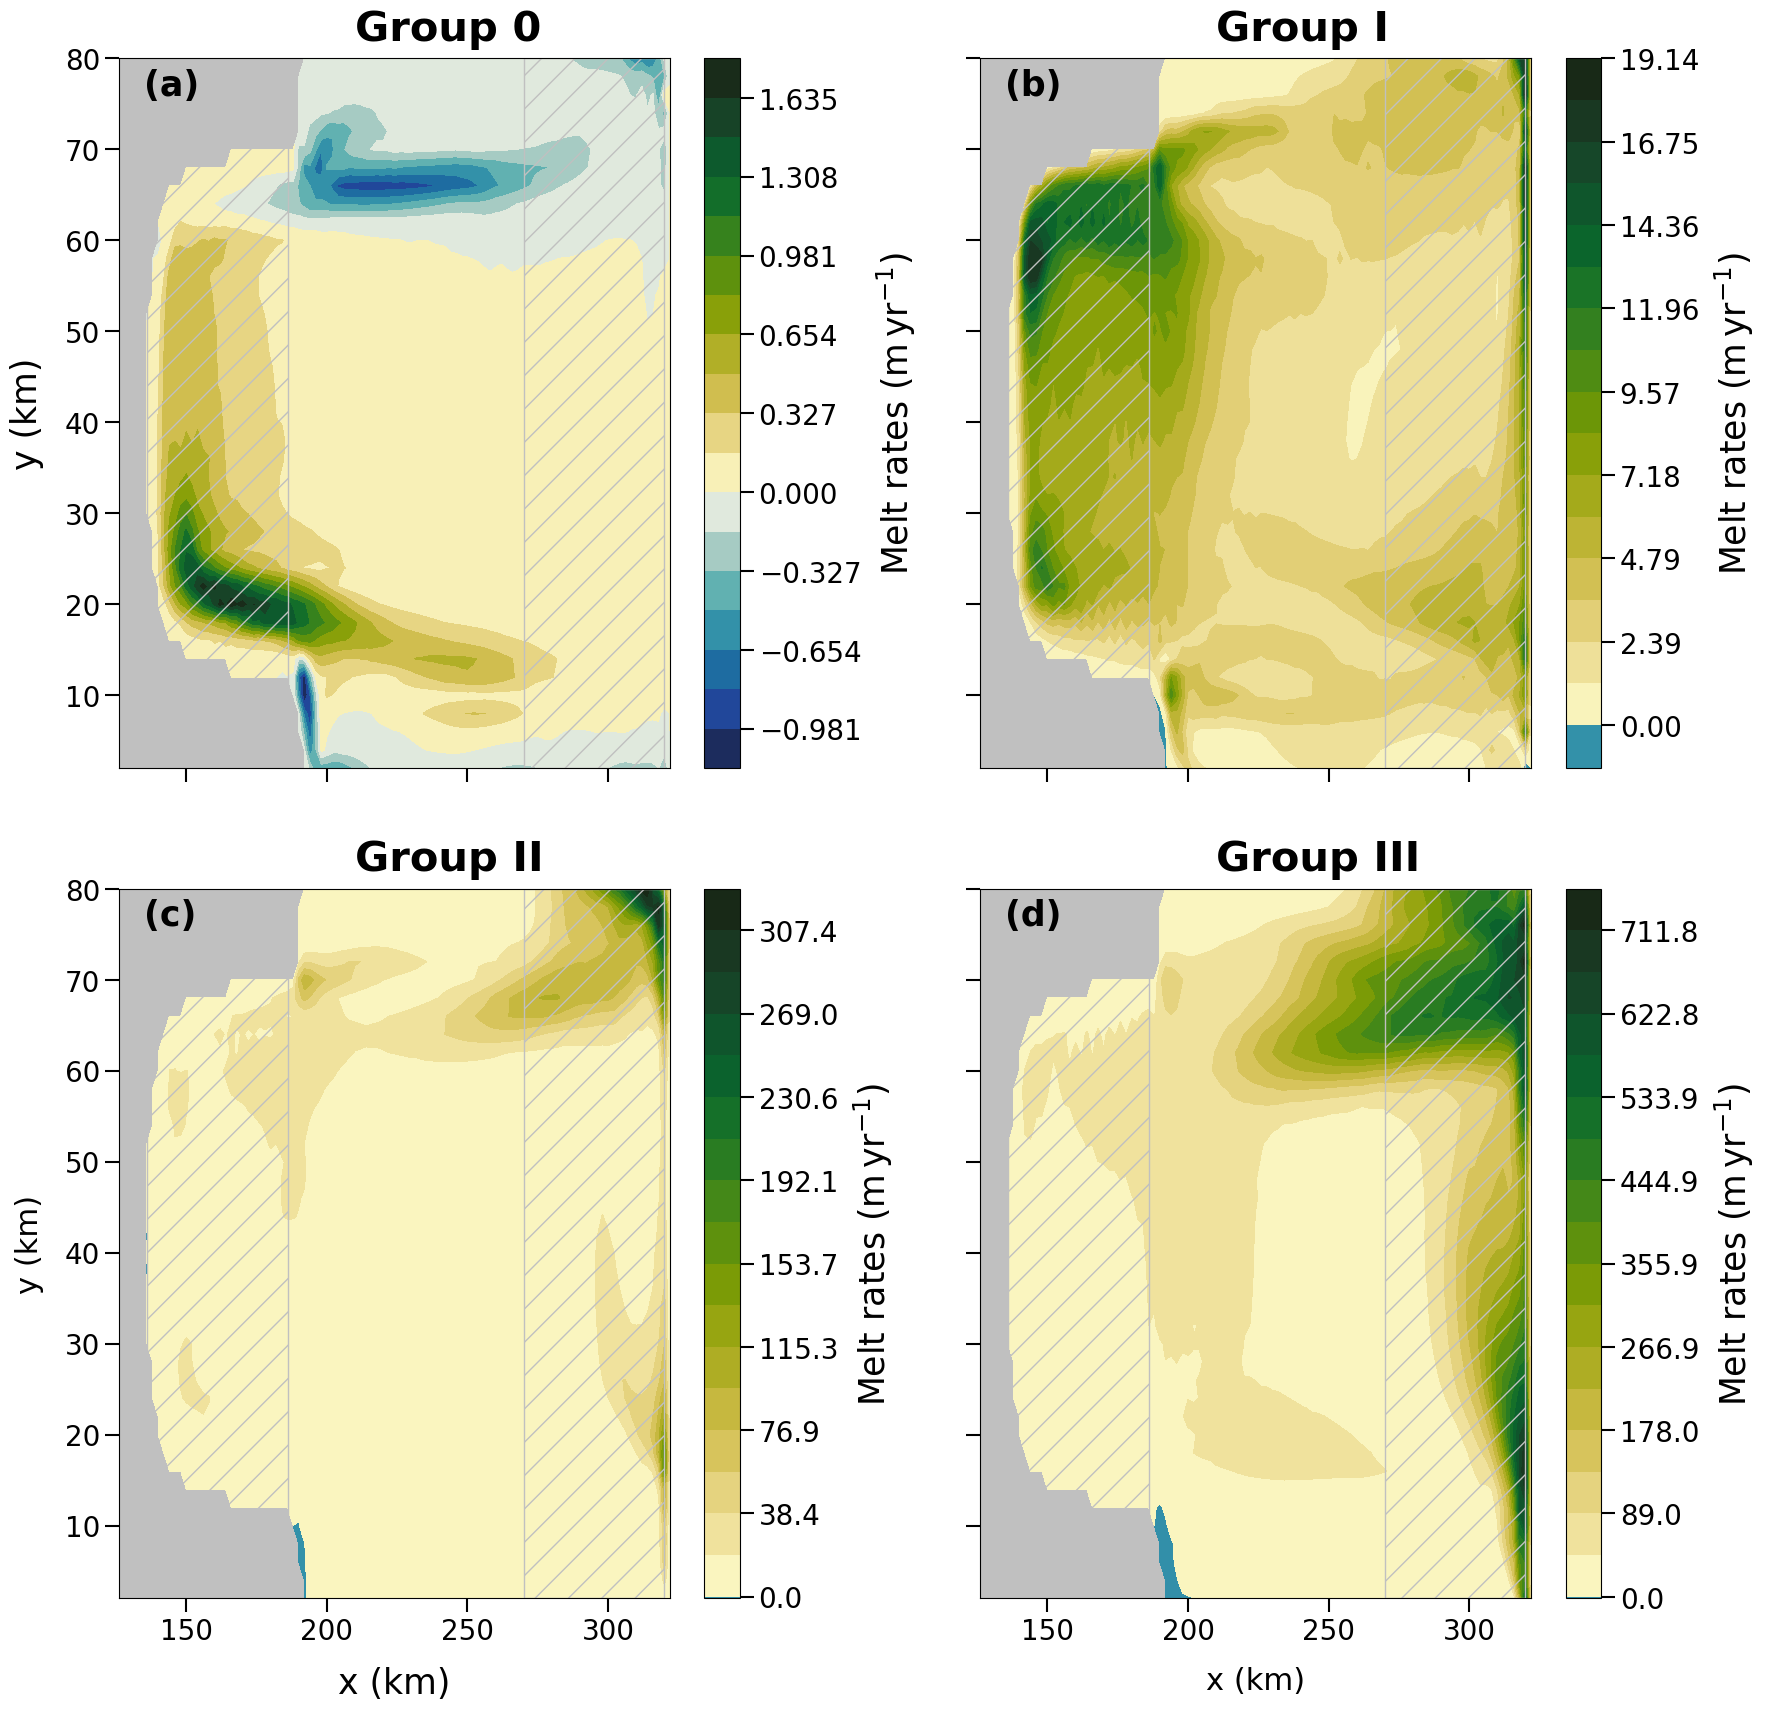

In [43]:
#create the figure
fig_melt,((ax11m,ax12m),(ax21m,ax22m))=plt.subplots(2,2,figsize=(20,20),sharex=True, sharey=True)
fig_melt.subplots_adjust(wspace=0.25,hspace=0.17)

axesm=[ax11m,ax12m,ax21m,ax22m]

#define some labels
label_subfigm=["(a)", "(b)", "(c)", "(d)"]
titre_subfigm=["Group 0", "Group I", "Group II", "Group III"]

#iterate over the axes/groups
for lm in range(len(axesm)):
    val_minm=fonte_yrmoy_groups[lm].min(axis=(0,1)); val_maxm=fonte_yrmoy_groups[lm].max(axis=(0,1)) #min/max values
    #plot the melt maps
    if lm==0: #group0
        cfm=axesm[lm].contourf(fonte_yrmoy_groups[lm].x[xpos_gl-40:xpos_frontr+1]*2,fonte_yrmoy_groups[lm].y[1:-1]*2,(fonte_yrmoy_groups[lm]*shelf_norm)[1:-1,xpos_gl-40:xpos_frontr+1],levels=np.arange(val_minm,val_maxm+np.abs(val_minm)/7,np.abs(val_minm)/7),cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vcenter=0))
    elif lm==1: #groupI
        cfm=axesm[lm].contourf(fonte_yrmoy_groups[lm].x[xpos_gl-40:xpos_frontr+1]*2,fonte_yrmoy_groups[lm].y[1:-1]*2,(fonte_yrmoy_groups[lm]*shelf_norm)[1:-1,xpos_gl-40:xpos_frontr+1],levels=np.concatenate((np.array([val_minm]),np.linspace(0.0,val_maxm,17))),cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vcenter=0))
    else:
        cfm=axesm[lm].contourf(fonte_yrmoy_groups[lm].x[xpos_gl-40:xpos_frontr+1]*2,fonte_yrmoy_groups[lm].y[1:-1]*2,(fonte_yrmoy_groups[lm]*shelf_norm)[1:-1,xpos_gl-40:xpos_frontr+1],levels=np.concatenate((np.array([val_minm]),np.linspace(0.0,val_maxm,18))),cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vcenter=0))
    #set up the colorbar
    cbarm=plt.colorbar(cfm,spacing="proportional")
    cbarm.set_label(label="Melt rates ("+r"$\mathrm{m\,yr^{-1}}$"+")",size=25,labelpad=10)
    cbarm.ax.tick_params(labelsize=20,size=10,width=1.5)
    
    #display the area close to the grounding line used to compute the mean
    area_close_gl = patches.Rectangle(((xpos_gl)*2, 2), critere_nbre_km, 78, edgecolor='silver',fill=False, hatch="/",alpha=1)
    axesm[lm].add_patch(area_close_gl)
    
    #display the area close to the front used to compute the mean
    area_close_front = patches.Rectangle(((xpos_frontr-critere_nbre_km//2-1)*2, 2), critere_nbre_km, 78, edgecolor='silver',fill=False, hatch="/",alpha=1)
    axesm[lm].add_patch(area_close_front)
    
    axesm[lm].set_facecolor("silver")
    
    #labels subfigures
    axesm[lm].text(65+70,66+10,label_subfigm[lm],color="black",fontweight="bold",fontsize=25)
    axesm[lm].text(180+30,82,titre_subfigm[lm],color="black",fontweight="bold",fontsize=30)
    
    #set up the axes
    axesm[lm].tick_params(axis="both",labelsize=20,size=10,width=1.5)
    axesm[lm].set_xlim((xpos_gl-5)*2,(xpos_frontr)*2)
    
axesm[2].set_xlabel("x (km)",fontsize=25,labelpad=15);axesm[3].set_xlabel("x (km)",fontsize=22,labelpad=15) 
axesm[0].set_ylabel("y (km)",fontsize=25,labelpad=15);axesm[2].set_ylabel("y (km)",fontsize=22,labelpad=15)

plt.show()

#save the figure
#fig_melt.savefig("figure_melt_article.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

**Buoyancy fluxes**

In [44]:
#compute the mean over the cavity
Fflot_moy_cavity_num=[] ; Fflot_moy_cavity=[]

for lfg in range(4):
    print("Groupe ",lfg)
    Fflot_moy_cavity_num.append((Fflot_yrmoy_groups[lfg][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))).values)
    exponent=fexponent(Fflot_moy_cavity_num[lfg])
    Fflot_moy_cavity.append(r"$\mathbf{"+str(np.round(Fflot_moy_cavity_num[lfg]*10**(-exponent),2))+"\\times10^{"+str(exponent)+"}}$")
print(Fflot_moy_cavity_num)
print(Fflot_moy_cavity)

Groupe  0
Groupe  1
Groupe  2
Groupe  3
[array(8.74361198e-08), array(3.85579678e-06), array(5.74016852e-06), array(-4.41006409e-05)]
['$\\mathbf{8.74\\times10^{-8}}$', '$\\mathbf{3.86\\times10^{-6}}$', '$\\mathbf{5.74\\times10^{-6}}$', '$\\mathbf{-4.41\\times10^{-5}}$']


31
[-1.71266697e-06 -1.57000417e-06 -1.42734136e-06 -1.28467856e-06
 -1.14201575e-06 -9.99352948e-07 -8.56690143e-07 -7.14027338e-07
 -5.71364533e-07 -4.28701728e-07 -2.86038924e-07 -1.43376119e-07
 -7.13314024e-10  0.00000000e+00  1.42662805e-07  2.85325610e-07
  4.27988414e-07  5.70651219e-07  7.13314024e-07  8.55976829e-07
  9.98639634e-07  1.14130244e-06  1.28396524e-06  1.42662805e-06
  1.56929085e-06  1.71195366e-06  1.85461646e-06  1.99727927e-06
  2.13994207e-06  2.28260488e-06  2.42526768e-06]
30
[-1.88556987e-06 -1.08319971e-06 -2.80829556e-07  0.00000000e+00
  8.02370159e-07  1.60474032e-06  2.40711048e-06  3.20948063e-06
  4.01185079e-06  4.81422095e-06  5.61659111e-06  6.41896127e-06
  7.22133143e-06  8.02370159e-06  8.82607174e-06  9.62844190e-06
  1.04308121e-05  1.12331822e-05  1.20355524e-05  1.28379225e-05
  1.36402927e-05  1.44426629e-05  1.52450330e-05  1.60474032e-05
  1.68497733e-05  1.76521435e-05  1.84545136e-05  1.92568838e-05
  2.00592540e-05  2.08616241e-05]


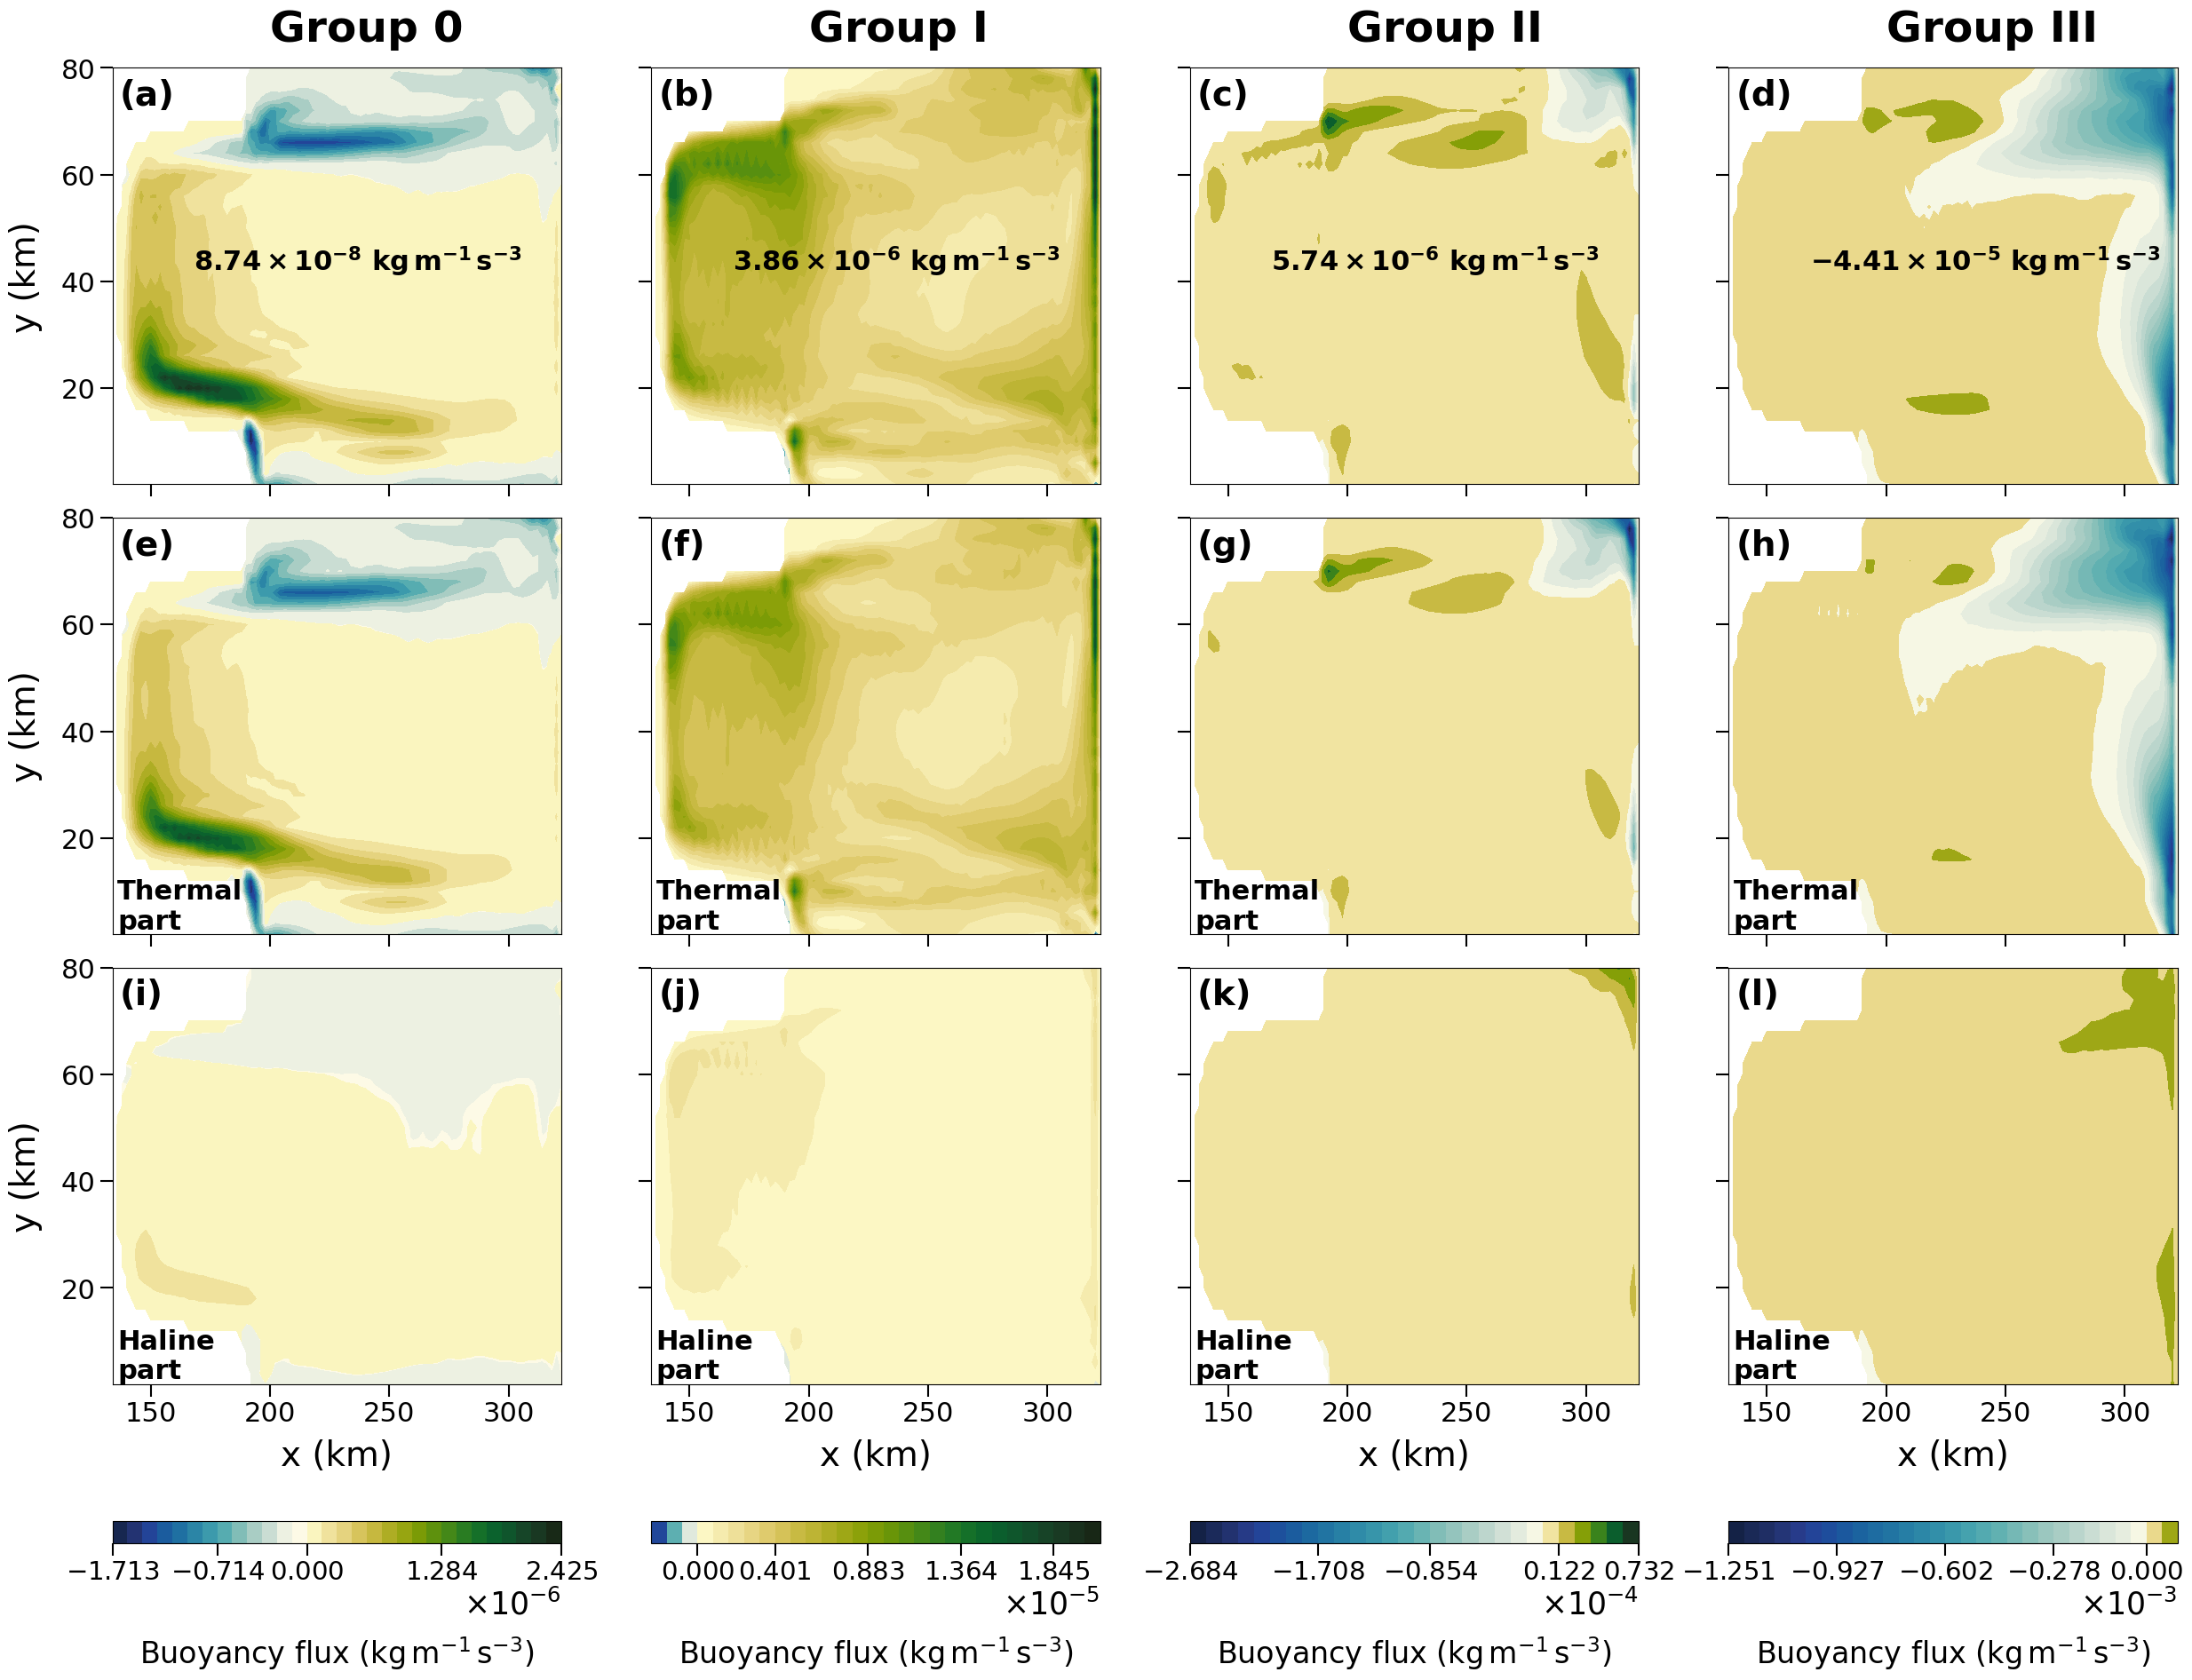

In [45]:
#create the figure
fig_Ffts,((ax11f,ax12f,ax13f,ax14f),(ax21f,ax22f,ax23f,ax24f),(ax31f,ax32f,ax33f,ax44f))=plt.subplots(3,4,figsize=(30,25),sharex=True,sharey=True)
fig_Ffts.subplots_adjust(wspace=0.2,hspace=0.08)

axesf=[(ax11f,ax12f,ax13f,ax14f),(ax21f,ax22f,ax23f,ax24f),(ax31f,ax32f,ax33f,ax44f)]
#some labels
num_subfigFflot=[("(a)","(b)","(c)","(d)"),("(e)","(f)","(g)","(h)"),("(i)","(j)","(k)","(l)")]
nom_groupesFflot=["Group 0","Group I","Group II","Group III"]

#some display variables
atenu_groups=[(0.0,0.0),(0.0,0.0),(0.0,0.0),(0.0,1.0e-4)]
div_groups=[12.005,2.35,22,27]
xticksflot_groups=[[0,7,13,22,-1],[3,8,14,20,26,-1],[0,8,15,23,-1],[0,7,14,21,27]]

#iteration over the groups
for lf in range(4):
    #global colorbar
    val_minff=Fflot_yrmoy_groups[lf].min(axis=(0,1)) ; val_maxff=Fflot_yrmoy_groups[lf].max(axis=(0,1))
    val_minft=Ftherm_yrmoy_groups[lf].min(axis=(0,1)) ; val_maxft=Ftherm_yrmoy_groups[lf].max(axis=(0,1))
    val_minfs=Fsaline_yrmoy_groups[lf].min(axis=(0,1)) ; val_maxfs=Fsaline_yrmoy_groups[lf].max(axis=(0,1))

    val_minfflotg=np.min([val_minff,val_minft,val_minfs])
    val_maxfflotg=np.max([val_maxff,val_maxft,val_maxfs])
    
    levels_Fflot=np.concatenate((np.arange(val_minfflotg,0.0+np.abs(val_minfflotg)/div_groups[lf],np.abs(val_minfflotg)/div_groups[lf])[:-1],np.arange(0.0,val_maxfflotg+np.abs(val_minfflotg)/div_groups[lf],np.abs(val_minfflotg)/div_groups[lf])))
    print(len(levels_Fflot))
    print(levels_Fflot)
    
    #Fflot
    cfff=axesf[0][lf].contourf(Fflot_yrmoy_groups[lf].x[xpos_gl-1:xpos_frontr+1]*2,Fflot_yrmoy_groups[lf].y[1:-1]*2,(Fflot_yrmoy_groups[lf]*shelf_norm)[1:-1,xpos_gl-1:xpos_frontr+1],levels=levels_Fflot,cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vmin=levels_Fflot[0]+atenu_groups[lf][0],vcenter=0,vmax=levels_Fflot[-1]+atenu_groups[lf][-1]))

        #set up axes
    axesf[0][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)

        #some labels
    axesf[0][lf].text(137,73,num_subfigFflot[0][lf],fontsize=28,fontweight="bold")
    axesf[0][lf].text(200,85,nom_groupesFflot[lf],fontsize=35,fontweight="bold")


        #display the mean over the cavity
    
    axesf[0][lf].text(168,37+5,Fflot_moy_cavity[lf]+" "+r"$\mathrm{\mathbf{kg\,m^{-1}\,s^{-3}}}$",color="black",fontweight="bold",fontsize=22)
    
    #Ftherm
    cfft=axesf[1][lf].contourf(Ftherm_yrmoy_groups[lf].x[xpos_gl-1:xpos_frontr+1]*2,Ftherm_yrmoy_groups[lf].y[1:-1]*2,(Ftherm_yrmoy_groups[lf]*shelf_norm)[1:-1,xpos_gl-1:xpos_frontr+1],levels=levels_Fflot,cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vmin=levels_Fflot[0]+atenu_groups[lf][0],vcenter=0,vmax=levels_Fflot[-1]+atenu_groups[lf][-1]))
    
        #set up the axes
    axesf[1][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)

        #some labels
    axesf[1][lf].text(137,73,num_subfigFflot[1][lf],fontsize=28,fontweight="bold")
    axesf[1][lf].text(136,3,'\n'.join(("Thermal","part")),fontsize=22,fontweight="bold")

    
    #Fsaline
    cffs=axesf[2][lf].contourf(Fsaline_yrmoy_groups[lf].x[xpos_gl-1:xpos_frontr+1]*2,Fsaline_yrmoy_groups[lf].y[1:-1]*2,(Fsaline_yrmoy_groups[lf]*shelf_norm)[1:-1,xpos_gl-1:xpos_frontr+1],levels=levels_Fflot,cmap=cmo.delta,norm = mcolors.TwoSlopeNorm(vmin=levels_Fflot[0]+atenu_groups[lf][0],vcenter=0,vmax=levels_Fflot[-1]+atenu_groups[lf][-1]))
    
        #set up the axes
    axesf[2][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    axesf[2][lf].set_xlabel("x (km)",fontsize=28,labelpad=10)

        #some labels
    axesf[2][lf].text(137,73,num_subfigFflot[2][lf],fontsize=28,fontweight="bold")
    axesf[2][lf].text(136,3,'\n'.join(("Haline","part")),fontsize=22,fontweight="bold")

    
    #set up gloabal colorbar
    cbarffts=fig_Ffts.colorbar(cffs,ax=(axesf[0][lf],axesf[1][lf],axesf[2][lf]),location="bottom",pad=0.08)
    cbarffts.formatter.set_powerlimits((0, 0))
    cbarffts.formatter.set_useMathText(True)
    cbarffts.ax.xaxis.offsetText.set(size=25)
    cbarffts.ax.tick_params(labelsize=21,size=10,width=1.5)
    cbarffts.ax.set_xticks([levels_Fflot[xticksflot_groups[lf][0]],levels_Fflot[xticksflot_groups[lf][1]],\
                            levels_Fflot[xticksflot_groups[lf][2]],levels_Fflot[xticksflot_groups[lf][3]],\
                            levels_Fflot[xticksflot_groups[lf][4]]])
    cbarffts.set_label(label="Buoyancy flux ("+r"$\mathrm{kg\,m^{-1}\,s^{-3}}$"+")",size=24,labelpad=40)
    
#set up axes
axesf[0][0].set_ylabel("y (km)",fontsize=28,labelpad=15);axesf[1][0].set_ylabel("y (km)",fontsize=28,labelpad=15);axesf[2][0].set_ylabel("y (km)",fontsize=28,labelpad=15)

plt.show()
#save the figure
#fig_Ffts.savefig("figure_Fflot_article.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

**overturning**

In [46]:
#compute extremum values along z-axis (min or max depending on the sign)
OVT_zextremum=[[] for k in range(nbre_experiences)]
for l in range(nbre_experiences):
    ID_zminmax=(OVT_yrmoy[l]*mask_shelf_calcul_zx).get_axis_num("depthu")
    print(ID_zminmax)
    posextreme=(np.abs(OVT_yrmoy[l]*mask_shelf_calcul_zx.fillna(0))).argmax(axis=ID_zminmax)
    for ix in range(size_x):
        OVT_zextremum[l].append((OVT_yrmoy[l][posextreme[ix],ix])*mask_shelf_calcul_zx[posextreme[ix],ix])

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [47]:
print(len(OVT_zextremum)==nbre_experiences)

True


In [48]:
#some labels
print(nom_experiences)

labels_OVT=["S 0.001 g/kg ; T 0.1°C", "T 1°C", "T 1-2°C", "T 1-3°C", "T 3°C","T 6°C","T 6-4°C","T 8°C","T 8-4°C","T 8-6°C","T 10°C",\
"T 10-6°C","T 10-8°C","S 0.3 g/kg ; T 0.1°C","","","","","","","","","","","","","S 0.6 g/kg ; T 0.1°C","","","","","","T 6-4°C","","",\
"","","","","S 0.9 g/kg ; T 0.1°C","","","","","","","","","T 8-6°C","","",""]

#print(labels_OVT)

['S0_001_T0_1', 'S0_001_T1', 'S0_001_T1-2', 'S0_001_T1-3', 'S0_001_T3', 'S0_001_T6', 'S0_001_T6-4', 'S0_001_T8', 'S0_001_T8-4', 'S0_001_T8-6', 'S0_001_T10', 'S0_001_T10-6', 'S0_001_T10-8', 'S0_3_T0_1', 'S0_3_T1', 'S0_3_T1-2', 'S0_3_T1-3', 'S0_3_T3', 'S0_3_T6', 'S0_3_T6-4', 'S0_3_T8', 'S0_3_T8-4', 'S0_3_T8-6', 'S0_3_T10', 'S0_3_T10-6', 'S0_3_T10-8', 'S0_6_T0_1', 'S0_6_T1', 'S0_6_T1-2', 'S0_6_T1-3', 'S0_6_T3', 'S0_6_T6', 'S0_6_T6-4', 'S0_6_T8', 'S0_6_T8-4', 'S0_6_T8-6', 'S0_6_T10', 'S0_6_T10-6', 'S0_6_T10-8', 'S0_9_T0_1', 'S0_9_T1', 'S0_9_T1-2', 'S0_9_T1-3', 'S0_9_T3', 'S0_9_T6', 'S0_9_T6-4', 'S0_9_T8', 'S0_9_T8-4', 'S0_9_T8-6', 'S0_9_T10', 'S0_9_T10-6', 'S0_9_T10-8']


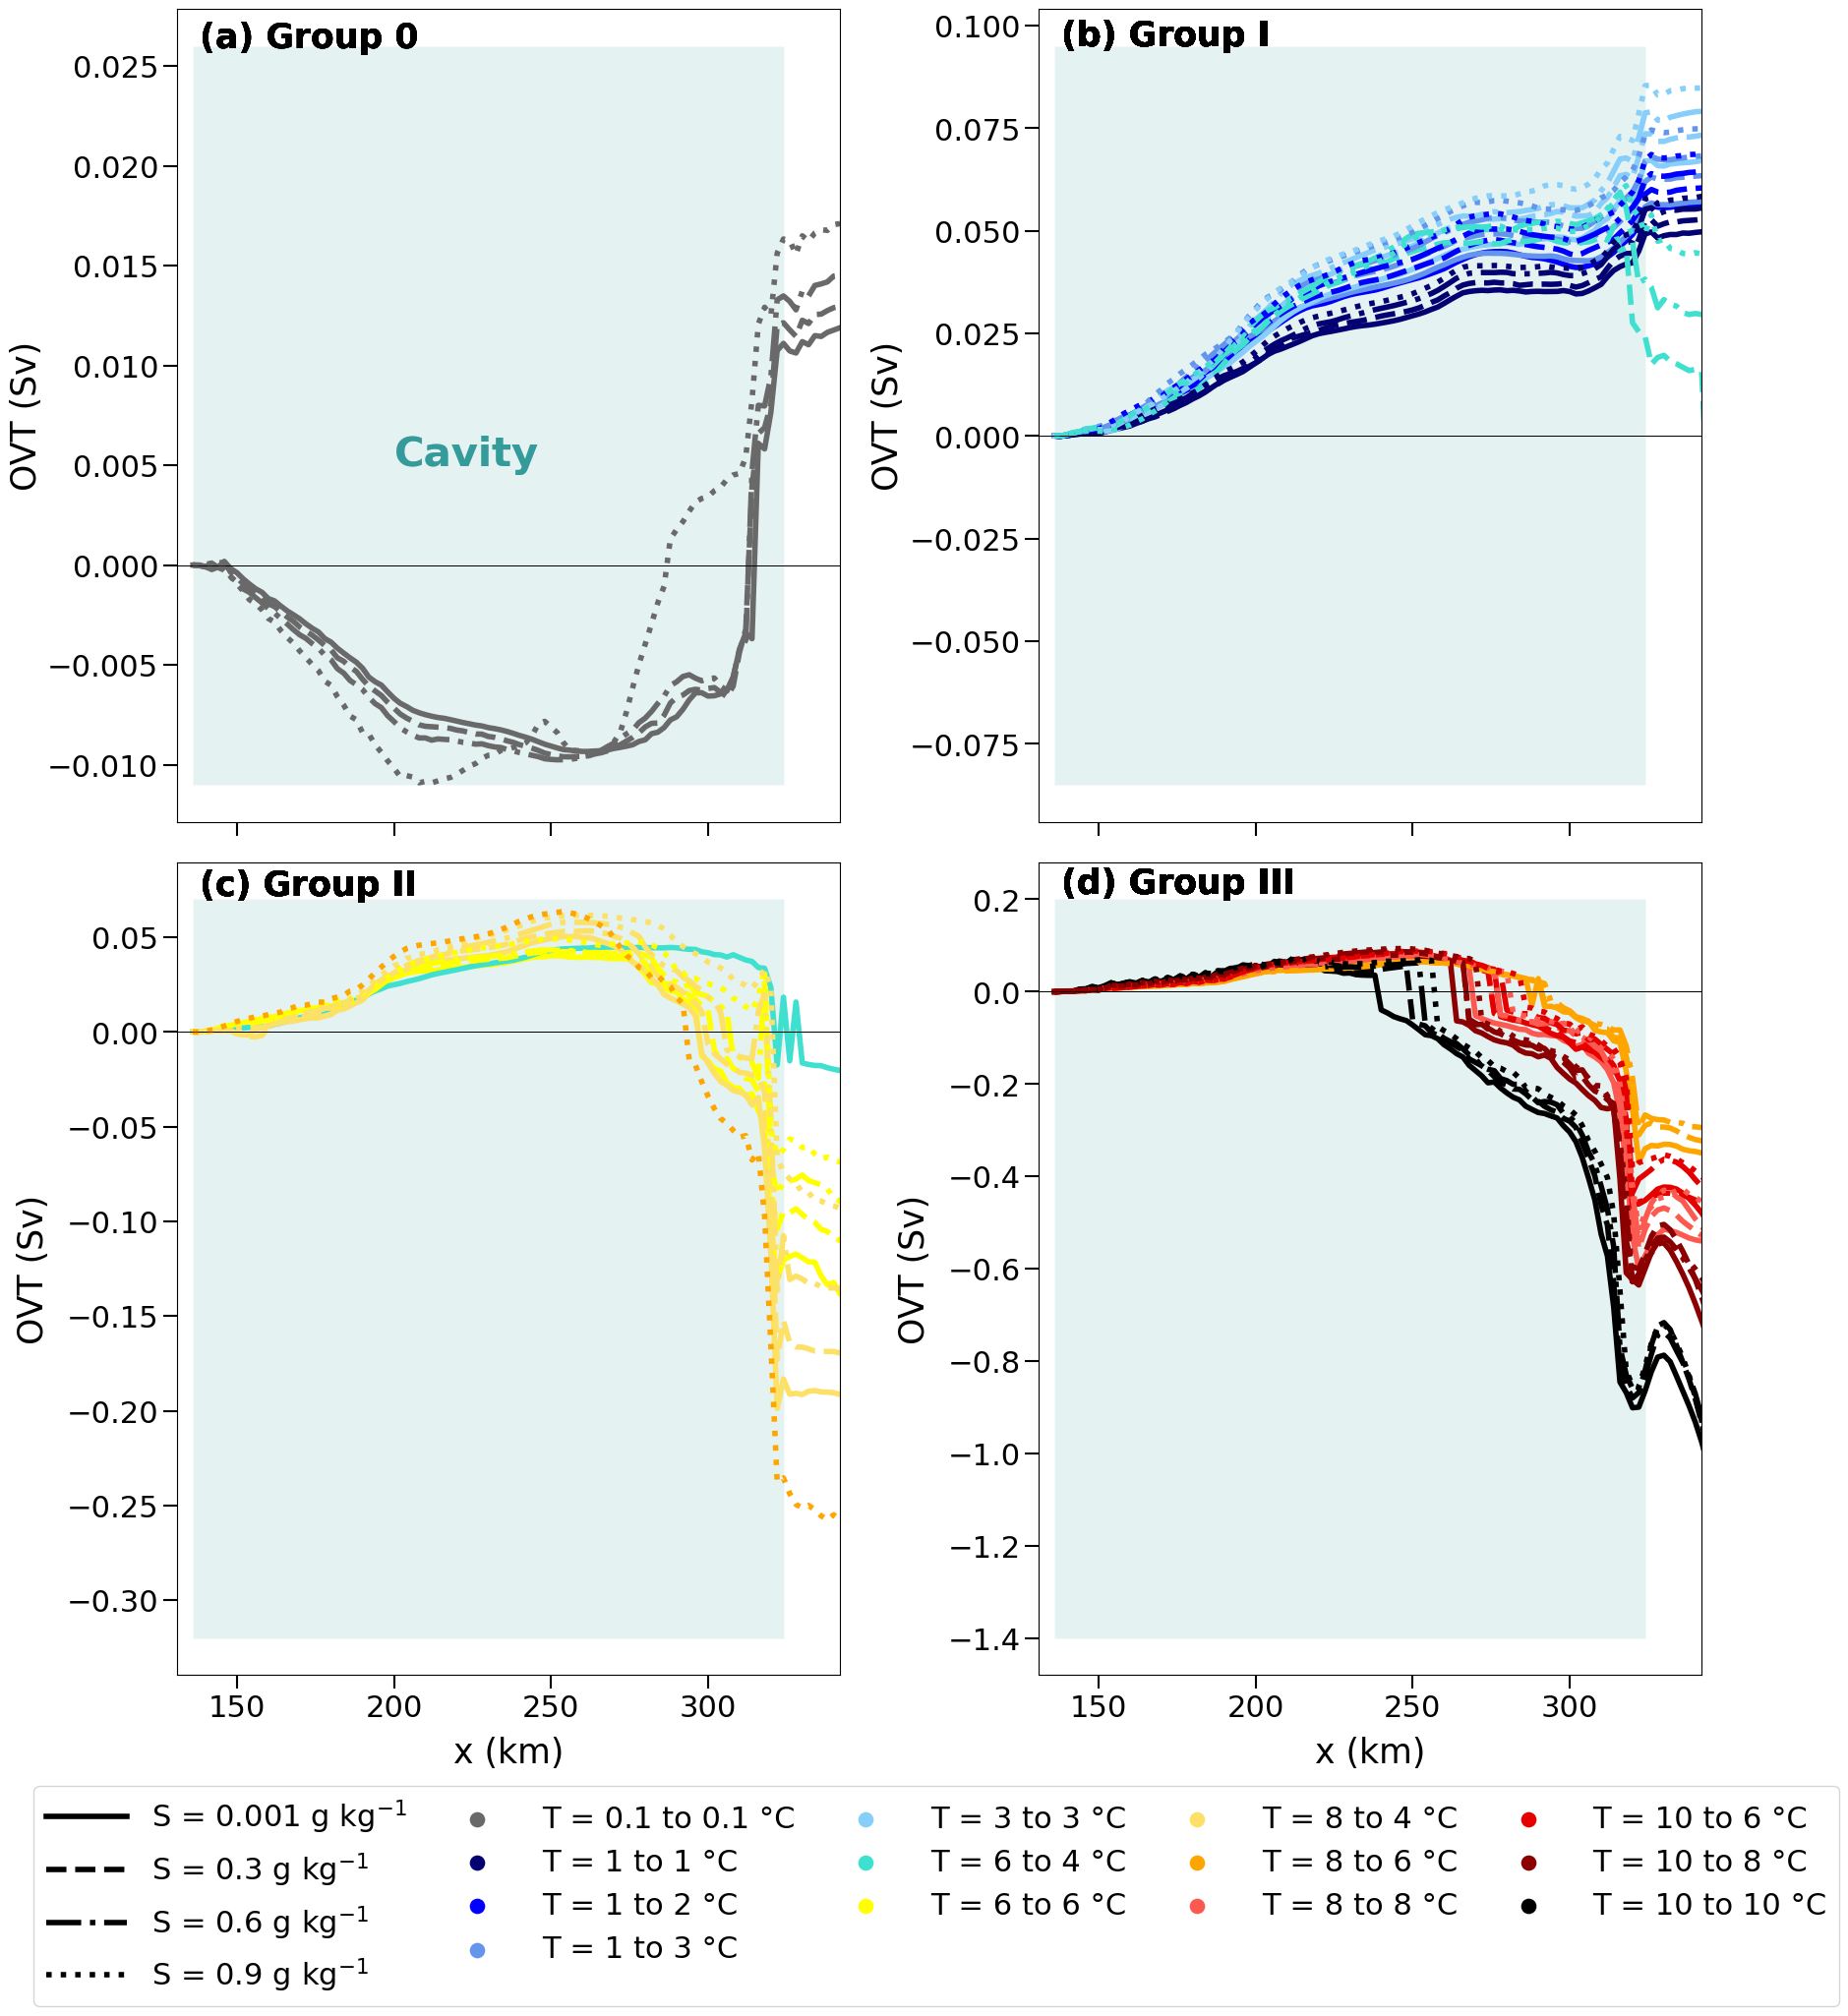

In [49]:
#create the figure
fig_OVT,((ax11o,ax12o),(ax21o,ax22o))=plt.subplots(2,2,figsize=(20,22),sharex=True)
fig_OVT.subplots_adjust(wspace=0.3,hspace=0.05)

axeso=[ax11o,ax12o,ax21o,ax22o]

#iteration over the experients
for lo in range(nbre_experiences):
    #print(nom_experiences[lo],couleurs_experiences[lo%nbre_temp_diff],ligne_style_experiences[lo])
    
    if lo in Group0: #Group 0
        axeso[0].plot(OVT_yrmoy[lo].x*2,OVT_zextremum[lo],color=couleurs_experiences[lo%nbre_temp_diff],linestyle=ligne_style_experiences[lo],lw=4)
        
        #set up the axes
        axeso[0].set_xlim(xpos_gl*2-5,xpos_frontr*2+20)
        axeso[0].set_ylabel("OVT (Sv)",fontsize=25,labelpad=3)
        axeso[0].tick_params(axis="both",labelsize=22,size=10,width=1.5)
        
        #set up some labels
        axeso[0].text(138,0.0262*0.99,"(a) Group 0",fontsize=25,fontweight="bold")
        axeso[0].text(200,0.005,"Cavity",fontsize=30,color="teal",fontweight="bold",alpha=0.3)
        
        #black line y=0
        axeso[0].plot(np.linspace(0,(size_x-1)*2,size_x),np.linspace(0,0,size_x),color="black",lw=0.5)
        
    elif lo in GroupI: #Group I
        axeso[1].plot(OVT_yrmoy[lo].x*2,OVT_zextremum[lo],color=couleurs_experiences[lo%nbre_temp_diff],linestyle=ligne_style_experiences[lo],lw=4)
        
        #set up the axes
        axeso[1].set_ylabel("OVT (Sv)",fontsize=25,labelpad=3)
        axeso[1].tick_params(axis="both",labelsize=22,size=10,width=1.5)
        
        #set up the name of the group
        axeso[1].text(138,0.096*0.99,"(b) Group I",fontsize=25,fontweight="bold")

        #black line y=0
        axeso[1].plot(np.linspace(0,(size_x-1)*2,size_x),np.linspace(0,0,size_x),color="black",lw=0.5)
        
    elif lo in GroupII: #Group II
        axeso[2].plot(OVT_yrmoy[lo].x*2,OVT_zextremum[lo],color=couleurs_experiences[lo%nbre_temp_diff],linestyle=ligne_style_experiences[lo],lw=4)
        
        #set up the axes
        axeso[2].set_xlabel("x (km)",fontsize=25,labelpad=10) ; axeso[2].set_ylabel("OVT (Sv)",fontsize=25,labelpad=12)
        axeso[2].tick_params(axis="both",labelsize=22,size=10,width=1.5)
        
        #set up the name of the group
        axeso[2].text(138,0.073*0.99,"(c) Group II",fontsize=25,fontweight="bold")

        #black line y=0
        axeso[2].plot(np.linspace(0,(size_x-1)*2,size_x),np.linspace(0,0,size_x),color="black",lw=0.5)
        
    elif lo in GroupIII: #Group III
        axeso[3].plot(OVT_yrmoy[lo].x*2,OVT_zextremum[lo],color=couleurs_experiences[lo%nbre_temp_diff],linestyle=ligne_style_experiences[lo],lw=4)
        
        #set up the axes
        axeso[3].set_xlabel("x (km)",fontsize=25,labelpad=10) ; axeso[3].set_ylabel("OVT (Sv)",fontsize=25,labelpad=12)
        axeso[3].tick_params(axis="both",labelsize=22,size=10,width=1.5)
        
        #set up the name of the group
        axeso[3].text(138,0.215*0.99,"(d) Group III",fontsize=25,fontweight="bold")

        #ligne noire y=0
        axeso[3].plot(np.linspace(0,(size_x-1)*2,size_x),np.linspace(0,0,size_x),color="black",lw=0.5)
        
#set up the patch for the cavity
square_cavity0 = patches.Rectangle((xpos_gl*2, -0.011), (xpos_frontr-xpos_gl+1)*2, 0.037, edgecolor='white', facecolor='teal',alpha=0.1)
axeso[0].add_patch(square_cavity0)
square_cavity1 = patches.Rectangle((xpos_gl*2, -0.085), (xpos_frontr-xpos_gl+1)*2, 0.18, edgecolor='white', facecolor='teal',alpha=0.1)
axeso[1].add_patch(square_cavity1)
square_cavity2 = patches.Rectangle((xpos_gl*2, -0.32), (xpos_frontr-xpos_gl+1)*2, 0.39, edgecolor='white', facecolor='teal',alpha=0.1)
axeso[2].add_patch(square_cavity2)
square_cavity3 = patches.Rectangle((xpos_gl*2, -1.4), (xpos_frontr-xpos_gl+1)*2, 1.6, edgecolor='white', facecolor='teal',alpha=0.1)
axeso[3].add_patch(square_cavity3)

#set up the legend

label_salinite=["S = 0.001 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.3 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.6 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.9 "+r"$\mathrm{g \ kg^{-1}}$"]
label_temperature=["T = 0.1 to 0.1 °C","T = 1 to 1 °C", "T = 1 to 2 °C", "T = 1 to 3 °C", "T = 3 to 3 °C", "T = 6 to 6 °C", "T = 6 to 4 °C",\
                   "T = 8 to 8 °C", "T = 8 to 4 °C", "T = 8 to 6 °C", "T = 10 to 10 °C", "T = 10 to 6 °C", "T = 10 to 8 °C"]
for lsal in range(nbre_salin_diff):
    axeso[0].plot(np.linspace(600,600,20),np.linspace(0,0,20),ls=ligne_style_experiences[lsal*nbre_temp_diff],lw=4,color="black",label=label_salinite[lsal])
for ltemp in [0,1,2,3,4,6,5,8,9,7,11,12,10]:
    axeso[0].scatter(600,0,marker="o",s=3*35,c=couleurs_experiences[ltemp],label=label_temperature[ltemp])

fig_OVT.legend(bbox_to_anchor=(0.511,-0.05),loc='lower center',fontsize=22,ncol=5,handlelength=2.7,columnspacing=1)
    

plt.show()
#save the figure
#fig_OVT.savefig("figure_OVT_article.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

## T-S diagram figure

**restoring profiles**

In [50]:
liste_salinite_num=[(0.001,0.001),(0.3,0.3),(0.6,0.6),(0.9,0.9)]
liste_temperature_num=[(0.1,0.1),(1,1),(1,2),(1,3),(3,3),(6,6),(6,4),(8,8),(8,4),(8,6),(10,10),(10,6),(10,8)]

In [51]:
profils_restoring=[] #a tuple per experiment
for sal_num in liste_salinite_num:
    for temp_num in liste_temperature_num:
        profil_sal=np.linspace(sal_num[0],sal_num[1],size_z-1)
        profil_temp=np.linspace(temp_num[0],temp_num[1],size_z-1)
        
        profils_restoring.append((profil_sal,profil_temp))

**profiles before the front**

In [52]:
#compute the profiles
print(xpos_dvtfront,critere_nbre_km)
profils_dvtfront=[]
for l in range(nbre_experiences):
    #load the experiment
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)

    #temporal mean
    profiltemp_yrmoy=exp.votemper[debmoy_yr:finmoy_yr+1,:,:,:].mean(axis=0)
    profilsal_yrmoy=exp.vosaline[debmoy_yr:finmoy_yr+1,:,:,:].mean(axis=0)

    #mean over the x-axis
    profiltemp_yrmoy50km=profiltemp_yrmoy[:,:,xpos_dvtfront:xpos_dvtfront+critere_nbre_km//2+1].mean(axis=2)
    profilsal_yrmoy50km=profilsal_yrmoy[:,:,xpos_dvtfront:xpos_dvtfront+critere_nbre_km//2+1].mean(axis=2)
    
    #mean over the y-axis
    profiltemp_dvtfront=profiltemp_yrmoy50km[:,1:-1].mean(axis=1)
    profilsal_dvtfront=profilsal_yrmoy50km[:,1:-1].mean(axis=1)

    #close the experiment file
    exp.close()

    #put the profiles in the list
    profils_dvtfront.append((profilsal_dvtfront,profiltemp_dvtfront))

165 50


In [53]:
print(len(profils_dvtfront)==nbre_experiences)

True


**T-S diagram**

In [54]:
#ranges of salinity, temperature and depth for the diagram
taille=501 #number of salinity and temperature values

#inferior and superior limits
SAmin=0 ; SAmax=1
CTmin=-1 ; CTmax=10
zmin=10 ; zmax=730

#define the range vectors
liste_SA=np.linspace(SAmin,SAmax,taille)
liste_CT=np.linspace(CTmin,CTmax,taille)
liste_z=np.linspace(zmin,zmax,size_z)
#print(liste_SA,liste_CT,liste_z)

In [55]:
#compute TOH and the sign of the melt derivative of density 
rapport=np.ones((len(liste_SA),len(liste_CT),len(liste_z)))*np.nan #TOH
signe=np.ones((len(liste_SA),len(liste_CT),len(liste_z)))*np.nan #sign of the melt derivative of density 

#computation at each depth
for iz in range(len(liste_z)):
    signe[0,:,iz]=(L/cp)*alphaSEOS(liste_SA[0],liste_CT,liste_z[iz],coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])-(liste_SA[0]*betaSEOS(liste_SA[0],liste_CT,liste_z[iz],coefs_beta[0],coefs_beta[1],coefs_beta[2],coefs_beta[3]))
    for iSA in range(1,len(liste_SA)): #TOH is not defined for salinity equals 0
        rapport[iSA,:,iz]=-(L/cp)*alphaSEOS(liste_SA[iSA],liste_CT,liste_z[iz],coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])/(liste_SA[iSA]*betaSEOS(liste_SA[iSA],liste_CT,liste_z[iz],coefs_beta[0],coefs_beta[1],coefs_beta[2],coefs_beta[3]))
        signe[iSA,:,iz]=(L/cp)*alphaSEOS(liste_SA[iSA],liste_CT,liste_z[iz],coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])-(liste_SA[iSA]*betaSEOS(liste_SA[iSA],liste_CT,liste_z[iz],coefs_beta[0],coefs_beta[1],coefs_beta[2],coefs_beta[3]))

In [56]:
#compute the decimal logarithm of the absolute value of TOH
rapport10=np.log10(np.abs(rapport))

**choose the depths for the figure**

In [57]:
#2 depths : about the depth of the ice draft of the front and maximal depth of the grounding line

    ##front position without penalisation
xpos_frontsp=1 #sp=without penalisation
while (True in (data_domain.rpi[0,1:-1,xpos_frontsp]==0.99))==True:
    xpos_frontsp+=1
xpos_frontsp-=1
print(xpos_frontsp)
#print(data_domain.rpi[0,1:-1,xpos_frontsp-1:xpos_frontsp+2].values)
    
    ##ice draft front depth
#print(data_domain.isf_draft[0,1:-1,xpos_frontsp].values)
icedraftfrontsp=data_domain.isf_draft[0,1:-1,xpos_frontsp].mean(axis=0).values
print(icedraftfrontsp)
pos_depth_icedraftfront=((icedraftfrontsp-20/2)//20).astype(int)
print(liste_z[pos_depth_icedraftfront])   
    
    ##max depth of the grounding line
print((data_domain.bottom_level[0,1:-1,xpos_gl]-1).values)
pos_depth_GL=(data_domain.bottom_level[0,:,xpos_gl]-1).max(axis=0).values
print(liste_z[pos_depth_GL])
#print(data_domain.rpi[pos_depth_GL,1:-1,xpos_gl].values)
#print(data_domain.rpot[pos_depth_GL,1:-1,xpos_gl].values)
#print(data_domain.rpl[pos_depth_GL,1:-1,xpos_gl].values)

160
158.58598
150.0
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 30 31 31 31 31 31 31 31 31 31
 31 30 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
630.0


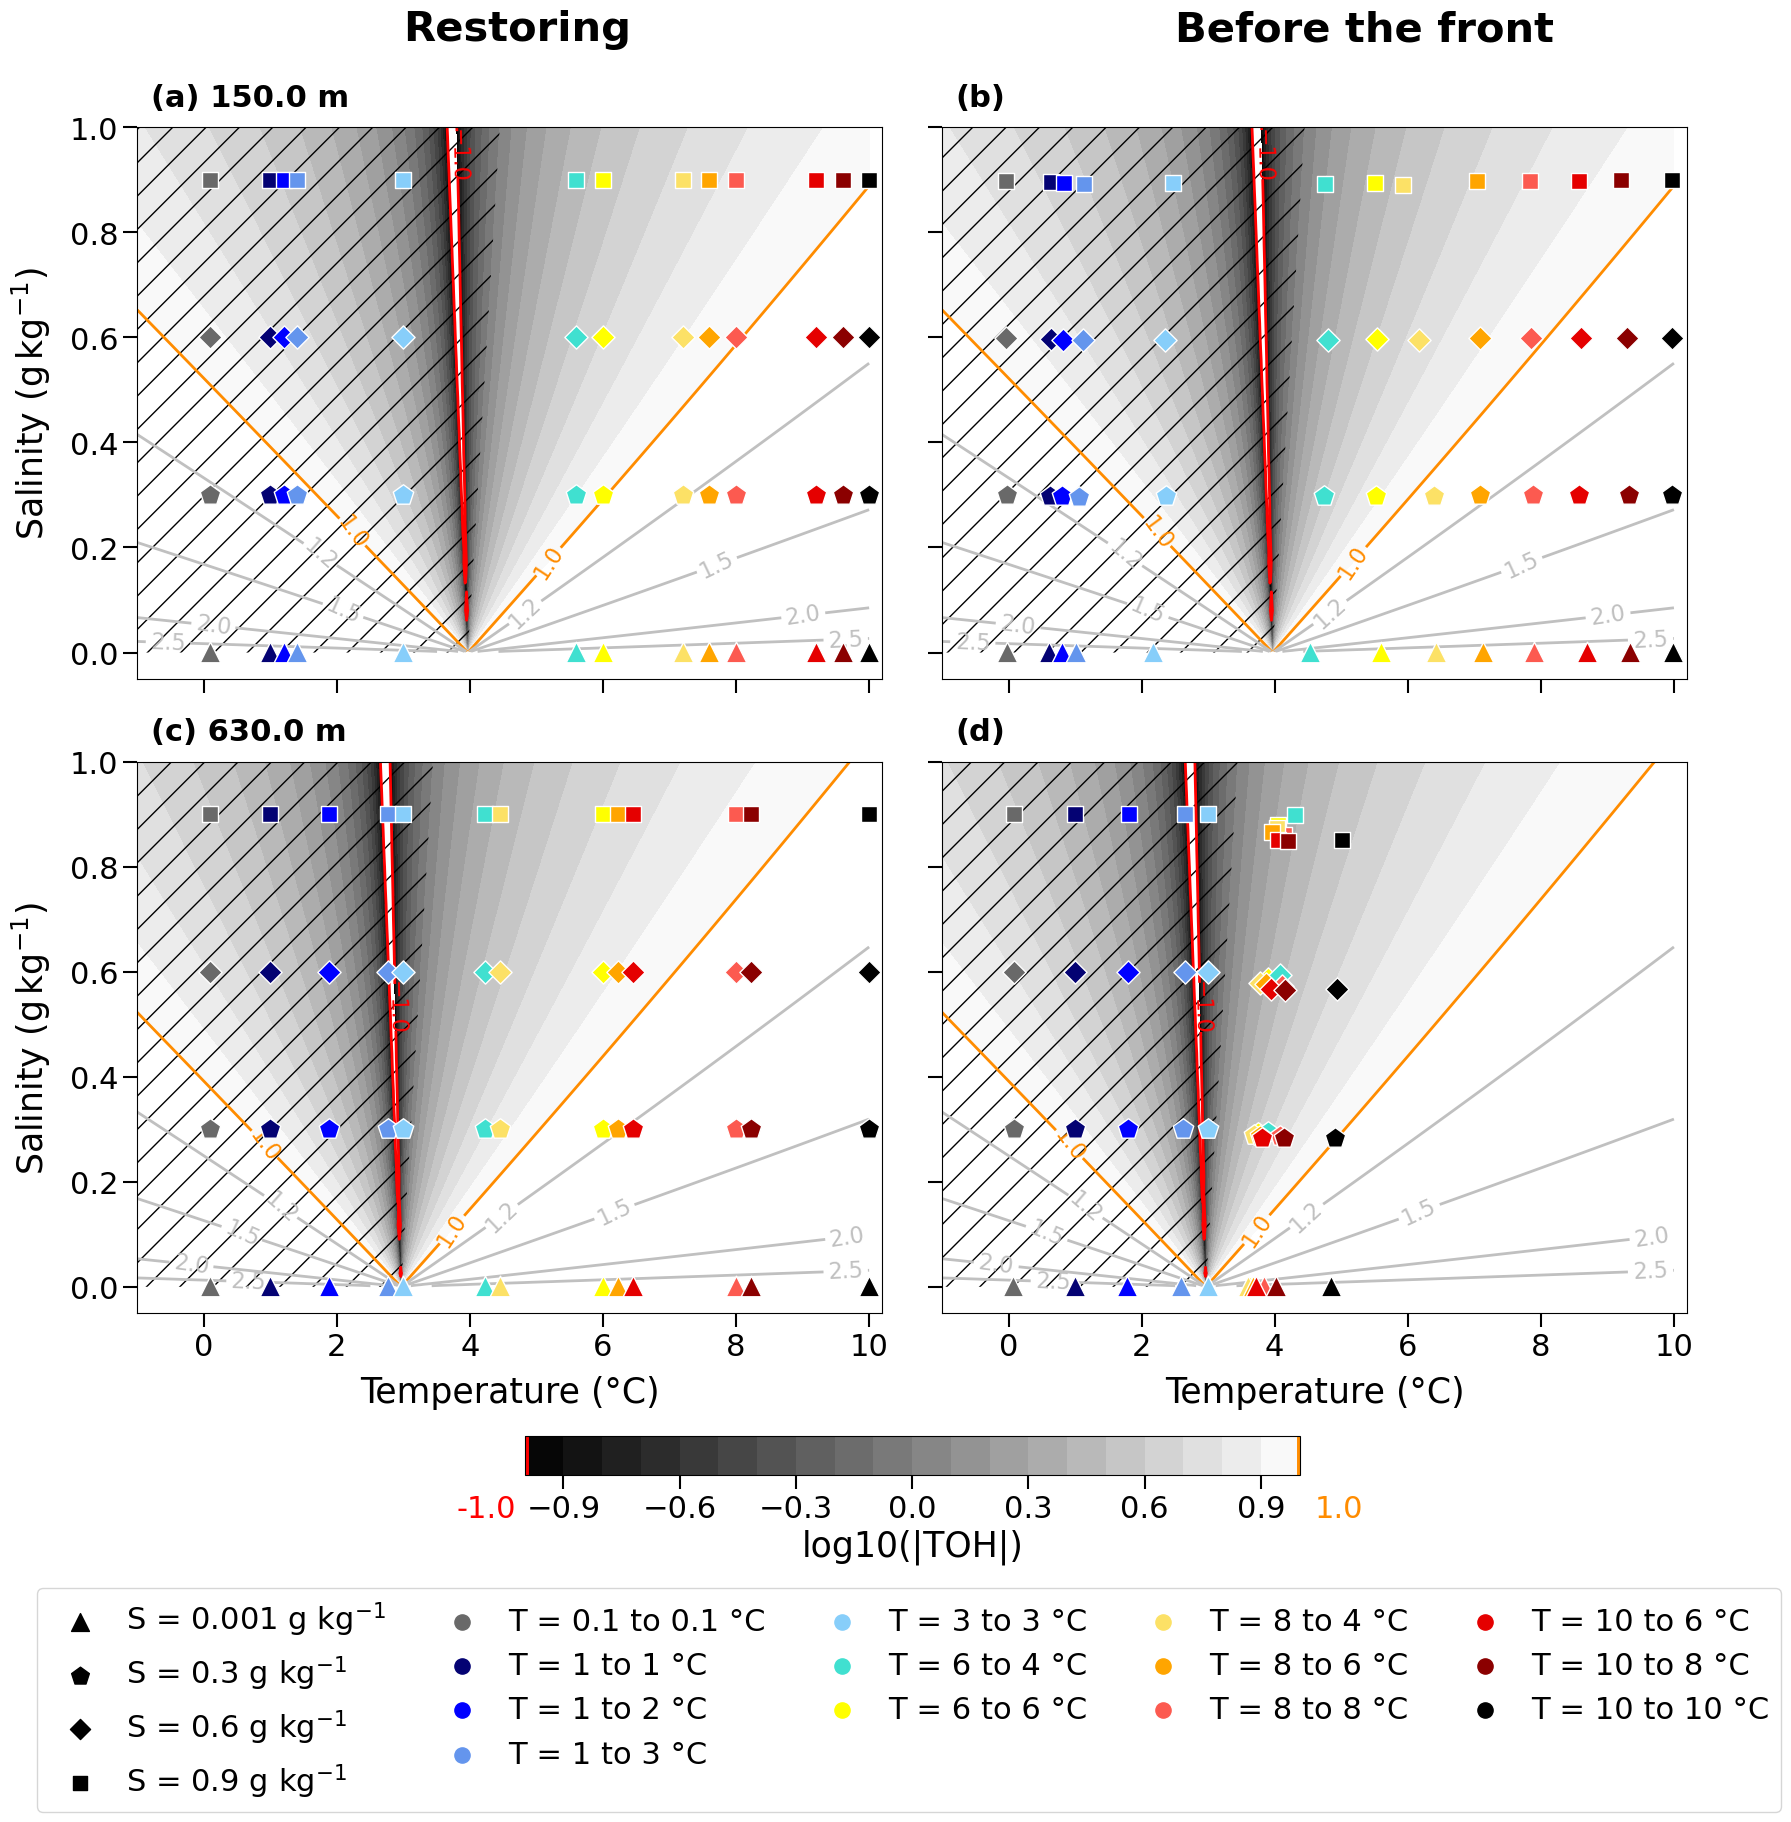

In [58]:
#create the figure
figdiagTSprofils,((ax11tsp,ax12tsp),(ax21tsp,ax22tsp))=plt.subplots(2,2,figsize=(20,20), sharey=True, sharex=True)
figdiagTSprofils.subplots_adjust(wspace=0.08,hspace=0.15)

axestsp=[(ax11tsp,ax12tsp),(ax21tsp,ax22tsp)]
#some labels
legend_subfigtsp=[("(a)","(b)"),("(c)","(d)")]
labels_tsp=["S 0.001 g/kg ; T 0.1°C", "T 1°C", "T 1-2°C", "T 1-3°C", "T 3°C","T 6°C","T 6-4°C","T 8°C","T 8-4°C","T 8-6°C","T 10°C",\
"T 10-6°C","T 10-8°C","S 0.3 g/kg ; T 0.1°C","","","","","","","","","","","","","S 0.6 g/kg ; T 0.1°C","","","","","","","","",\
"","","","","S 0.9 g/kg ; T 0.1°C","","","","","","","","","","","",""]

#iterate over the column
for ltsp in range(2):
    
    #display T-S diagram
        #depth of the ice draft of the front
    cf=axestsp[0][ltsp].contourf(liste_CT,liste_SA,rapport10[:,:,pos_depth_icedraftfront],levels=np.linspace(-1,1,21),zorder=-1,cmap="gist_yarg_r")
    c=axestsp[0][ltsp].contour(liste_CT,liste_SA,rapport10[:,:,pos_depth_icedraftfront],levels=[-1,1,1.2,1.5,2,2.5],colors=["red","darkorange","silver","silver","silver","silver"],zorder=0,linewidths=2)
    plt.clabel(c, inline=True, fontsize=16)
    cfhatches_front=axestsp[0][ltsp].contourf(liste_CT,liste_SA,signe[:,:,pos_depth_icedraftfront],levels=[np.min(signe[:,:,pos_depth_icedraftfront]),0,np.max(signe[:,:,pos_depth_icedraftfront])],colors="none",hatches=['/',None],zorder=-1)

        ##customise hatches
    for collection_front in cfhatches_front.collections:
        collection_front.set_edgecolor("black")
        collection_front.set_linewidth(0.)#no contours

        #max depth of the grounding line
    cf=axestsp[1][ltsp].contourf(liste_CT,liste_SA,rapport10[:,:,pos_depth_GL],levels=np.linspace(-1,1,21),zorder=-1,cmap="gist_yarg_r")
    c=axestsp[1][ltsp].contour(liste_CT,liste_SA,rapport10[:,:,pos_depth_GL],levels=[-1,1,1.2,1.5,2,2.5],colors=["red","darkorange","silver","silver","silver","silver"],zorder=0,linewidths=2)
    plt.clabel(c, inline=True, fontsize=16)
    cfhatches_GL=axestsp[1][ltsp].contourf(liste_CT,liste_SA,signe[:,:,pos_depth_GL],levels=[np.min(signe[:,:,pos_depth_GL]),0,np.max(signe[:,:,pos_depth_GL])],colors="none",hatches=['/',None],zorder=-1)

        ##customise hatches
    for collection_GL in cfhatches_GL.collections:
        collection_GL.set_edgecolor("black")
        collection_GL.set_linewidth(0.)#no contours
        
    
    #display profiles
    if ltsp==0: #restoring profiles
        for l in range(nbre_experiences):
            #axestsp[0][ltsp].scatter(profils_restoring[l][1][pos_depth_icedraftfront],profils_restoring[l][0][pos_depth_icedraftfront],marker=marker_style_experiences[l],s=3*marker_size_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],edgecolor="black",label=labels_tsp[l])
            axestsp[0][ltsp].scatter(profils_restoring[l][1][pos_depth_icedraftfront],profils_restoring[l][0][pos_depth_icedraftfront],marker=marker_style_experiences[l],s=4*marker_size_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],edgecolor="white",zorder=2)
            axestsp[1][ltsp].scatter(profils_restoring[l][1][pos_depth_GL],profils_restoring[l][0][pos_depth_GL],marker=marker_style_experiences[l],s=4*marker_size_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],edgecolor="white",zorder=2)
            
        #some labels
        axestsp[0][ltsp].text(3,1.06*1.1,"Restoring",fontsize=30,fontweight="bold")
        axestsp[0][ltsp].text(-0.8,1.02*1.02,legend_subfigtsp[0][ltsp]+" "+str(liste_z[pos_depth_icedraftfront])+" m",fontsize=22,fontweight="bold")
        axestsp[1][ltsp].text(-0.8,1.02*1.02,legend_subfigtsp[1][ltsp]+" "+str(liste_z[pos_depth_GL])+" m",fontsize=22,fontweight="bold")
        
        #legend of the axes
        axestsp[0][ltsp].set_ylabel("Salinity ("+r"$\mathrm{g\,kg^{-1}}$"+")",fontsize=25,labelpad=12)
        axestsp[1][ltsp].set_ylabel("Salinity ("+r"$\mathrm{g\,kg^{-1}}$"+")",fontsize=25,labelpad=12)
        
    elif ltsp==1: #profiles before the front
        for l in range(nbre_experiences):
            axestsp[0][ltsp].scatter(profils_dvtfront[l][1][pos_depth_icedraftfront],profils_dvtfront[l][0][pos_depth_icedraftfront],marker=marker_style_experiences[l],s=4*marker_size_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],edgecolor="white",zorder=2)
            axestsp[1][ltsp].scatter(profils_dvtfront[l][1][pos_depth_GL],profils_dvtfront[l][0][pos_depth_GL],marker=marker_style_experiences[l],s=4*marker_size_experiences[l],c=couleurs_experiences[l%nbre_temp_diff],edgecolor="white",zorder=2)
            
        #some labels
        axestsp[0][ltsp].text(2.5,1.06*1.1,"Before the front",fontsize=30,fontweight="bold")
        axestsp[0][ltsp].text(-0.8,1.02*1.02,legend_subfigtsp[0][ltsp],fontsize=22,fontweight="bold")
        axestsp[1][ltsp].text(-0.8,1.02*1.02,legend_subfigtsp[1][ltsp],fontsize=22,fontweight="bold")
    
    #set up the axes
    axestsp[0][ltsp].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    axestsp[1][ltsp].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    axestsp[0][ltsp].set_xlim(-1,10.2)
    axestsp[1][ltsp].set_ylim(-0.05,1)
    axestsp[1][ltsp].set_xlabel("Temperature (°C)",fontsize=25,labelpad=10)

#set up the legend
label_salinite=["S = 0.001 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.3 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.6 "+r"$\mathrm{g \ kg^{-1}}$","S = 0.9 "+r"$\mathrm{g \ kg^{-1}}$"]
label_temperature=["T = 0.1 to 0.1 °C","T = 1 to 1 °C", "T = 1 to 2 °C", "T = 1 to 3 °C", "T = 3 to 3 °C", "T = 6 to 6 °C", "T = 6 to 4 °C",\
                   "T = 8 to 8 °C", "T = 8 to 4 °C", "T = 8 to 6 °C", "T = 10 to 10 °C", "T = 10 to 6 °C", "T = 10 to 8 °C"]
for lsal in range(nbre_salin_diff):
    axestsp[0][0].scatter(0,12,marker=marker_style_experiences[lsal*nbre_temp_diff],s=3*marker_size_experiences[lsal*nbre_temp_diff],c="black",label=label_salinite[lsal])
for ltemp in [0,1,2,3,4,6,5,8,9,7,11,12,10]:
    axestsp[0][0].scatter(0,12,marker="o",s=3*40,c=couleurs_experiences[ltemp],label=label_temperature[ltemp])
    
figdiagTSprofils.legend(bbox_to_anchor=(0.511,0.03),loc='lower center',fontsize=22,ncol=5,columnspacing=1.5,handletextpad=0.5)
    
#set up the colorbar
cbartsp=figdiagTSprofils.colorbar(cf,ax=axestsp[0]+axestsp[1],location="bottom",pad=0.08,shrink=0.5)
cbartsp.set_label(label="log10(|TOH|)",size=25)
cbartsp.ax.tick_params(labelsize=22,size=10,width=1.5)
cbartsp.add_lines([-1,1],colors=["red","darkorange"],linewidths=5)
axestsp[1][0].text(3.8,-0.438,'-1.0',size=22,color="red")
axestsp[1][1].text(4.6,-0.438,'1.0',size=22,color="darkorange")
    
plt.show()
#save the figure
#figdiagTSprofils.savefig("figure_diagTSprofils.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

## Some computations to compare with Joughin et al. 2021

In [59]:
#compuate some means
fonte_moy_cavity_num=[-999.,-999.,-999.,-999.] #cavity
fonte_moy_gl_num=[-999.,-999.,-999.,-999.] #close grounding line
fonte_moy_front_num=[-999.,-999.,-999.,-999.] #close front

for lg in range(4):
    print("Groupe ",lg)
    fonte_moy_cavity_num[lg]=(fonte_yrmoy_groups[lg][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))).values
    fonte_moy_gl_num[lg]=(fonte_yrmoy_groups[lg][:,xpos_gl:xpos_gl+critere_nbre_km//2+1].sum(axis=(0,1))/shelf_norm0[:,xpos_gl:xpos_gl+critere_nbre_km//2+1].sum(axis=(0,1))).values
    fonte_moy_front_num[lg]=(fonte_yrmoy_groups[lg][:,xpos_frontr-critere_nbre_km//2-1:xpos_frontr].sum(axis=(0,1))/shelf_norm0[:,xpos_frontr-critere_nbre_km//2-1:xpos_frontr].sum(axis=(0,1))).values

Groupe  0
Groupe  1
Groupe  2
Groupe  3


In [60]:
#compute ranges of the mean melt rates over the cavity
range_fonte_moy_cavity_num=[[999.,-999.],[999.,-999.],[999.,-999.],[999.,-999.]] #ranges
exp_range_fonte_moy_cavity_num=[[999.,-999.],[999.,-999.],[999.,-999.],[999.,-999.]] #experiment corresponding to the min and max

liste_moy_fontecavity=[0 for l in range(nbre_experiences)]

print("Groupe 0")
for l0 in Group0:
    fonte_cavity_temp=fonte_yrmoy[l0][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))
    if fonte_cavity_temp<range_fonte_moy_cavity_num[0][0]:
        range_fonte_moy_cavity_num[0][0]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[0][0]=l0
    if fonte_cavity_temp>range_fonte_moy_cavity_num[0][1]:
        range_fonte_moy_cavity_num[0][1]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[0][1]=l0
    print(nom_experiences[l0],fonte_cavity_temp.values)
    liste_moy_fontecavity[l0]=fonte_cavity_temp

print("Groupe I")
for l1 in GroupI:
    fonte_cavity_temp=fonte_yrmoy[l1][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))
    if fonte_cavity_temp<range_fonte_moy_cavity_num[1][0]:
        range_fonte_moy_cavity_num[1][0]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[1][0]=l1
    if fonte_cavity_temp>range_fonte_moy_cavity_num[1][1]:
        range_fonte_moy_cavity_num[1][1]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[1][1]=l1
    print(nom_experiences[l1],fonte_cavity_temp.values)
    liste_moy_fontecavity[l1]=fonte_cavity_temp

print("Groupe II")
for l2 in GroupII:
    fonte_cavity_temp=fonte_yrmoy[l2][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))
    if fonte_cavity_temp<range_fonte_moy_cavity_num[2][0]:
        range_fonte_moy_cavity_num[2][0]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[2][0]=l2
    if fonte_cavity_temp>range_fonte_moy_cavity_num[2][1]:
        range_fonte_moy_cavity_num[2][1]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[2][1]=l2
    print(nom_experiences[l2],fonte_cavity_temp.values)
    liste_moy_fontecavity[l2]=fonte_cavity_temp

print("Groupe III")
for l3 in GroupIII:
    fonte_cavity_temp=fonte_yrmoy[l3][:,:xpos_frontr+1].sum(axis=(0,1))/shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))
    if fonte_cavity_temp<range_fonte_moy_cavity_num[3][0]:
        range_fonte_moy_cavity_num[3][0]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[3][0]=l3
    if fonte_cavity_temp>range_fonte_moy_cavity_num[3][1]:
        range_fonte_moy_cavity_num[3][1]=fonte_cavity_temp.values
        exp_range_fonte_moy_cavity_num[3][1]=l3
    print(nom_experiences[l3],fonte_cavity_temp.values)
    liste_moy_fontecavity[l3]=fonte_cavity_temp

Groupe 0
S0_001_T0_1 0.057240295607863256
S0_3_T0_1 0.06744627626326359
S0_6_T0_1 0.07544562696365624
S0_9_T0_1 0.08967063541402939
Groupe I
S0_001_T1 1.1242831598989873
S0_001_T1-2 2.2435078570340083
S0_001_T1-3 3.2867550550047833
S0_001_T3 4.523655012828964
S0_3_T1 1.2209336065047316
S0_3_T1-2 2.4289835102568897
S0_3_T1-3 3.5870618081632637
S0_3_T3 4.991661712676518
S0_3_T6-4 6.903065481190375
S0_6_T1 1.3198896266189812
S0_6_T1-2 2.5784011279785592
S0_6_T1-3 3.9132523353562183
S0_6_T3 5.465740599877549
S0_6_T6-4 7.322113921938416
S0_9_T1 1.3942465635493506
S0_9_T1-2 2.7678550989871273
S0_9_T1-3 4.270770188161853
S0_9_T3 5.806741385685419
S0_9_T6-4 7.8673339425331035
Groupe II
S0_001_T6 17.95913032856476
S0_001_T6-4 6.737255194446747
S0_001_T8-4 20.13351678406351
S0_3_T6 16.24015031328569
S0_3_T8-4 17.26433352062536
S0_6_T6 15.283188336392566
S0_6_T8-4 14.611174690220642
S0_9_T6 13.90513934683206
S0_9_T8-4 12.116092479407513
S0_9_T8-6 32.33547623435449
Groupe III
S0_001_T8 82.92331338

In [61]:
#convert melt rates in m/year in Gt/year (global over the cavité)

surface_tot_fonte_cavity=shelf_norm0[:,:xpos_frontr+1].sum(axis=(0,1))*2000*2000 #delta_x=2km et delta_y=2km
print(surface_tot_fonte_cavity.values)
for lgroupe in range(4):
    print("Group "+str(lgroupe))
    print("mean group",(fonte_moy_cavity_num[lgroupe]*rhofw*surface_tot_fonte_cavity*10**(-12)).values)
    print("min group",(range_fonte_moy_cavity_num[lgroupe][0]*rhofw*surface_tot_fonte_cavity*10**(-12)).values)
    print("max group",(range_fonte_moy_cavity_num[lgroupe][1]*rhofw*surface_tot_fonte_cavity*10**(-12)).values)
print("//")
print(fonte_moy_cavity_num)
print(range_fonte_moy_cavity_num)

13664000000.0
Group 0
mean group 0.9899664817939432
min group 0.7821313991858436
max group 1.2252595622972975
Group 1
mean group 52.51021406575605
min group 15.362205096859764
max group 107.49925099077232
Group 2
mean group 227.62236875660338
min group 92.05785497692034
max group 441.8319472662197
Group 3
mean group 1317.2185808773716
min group 505.9363066940728
max group 2339.963998142694
//
[array(0.07245071), array(3.84296063), array(16.65854572), array(96.40065727)]
[[array(0.0572403), array(0.08967064)], [array(1.12428316), array(7.86733394)], [array(6.73725519), array(32.33547623)], [array(37.02695453), array(171.2502926)]]


In [62]:
#display the min and max temperatures of the profiles before the front at two depths (ice draft and deepest grounding line)
#for the experiment with, respectively, the min and max melt rates for each group
for lgroupe in range(4):
    print("Group"+str(lgroupe))
    expmin=exp_range_fonte_moy_cavity_num[lgroupe][0]
    expmax=exp_range_fonte_moy_cavity_num[lgroupe][1]
    print("exp min front",(profils_dvtfront[expmin][1][pos_depth_icedraftfront]-(l_1*profils_dvtfront[expmin][0][pos_depth_icedraftfront]+l_2+l_3*rho0*g*(profils_dvtfront[expmin][1][pos_depth_icedraftfront].deptht-10)*10**(-4))).values)
    print("exp min GL",(profils_dvtfront[expmin][1][pos_depth_GL]-(l_1*profils_dvtfront[expmin][0][pos_depth_GL]+l_2+l_3*rho0*g*(profils_dvtfront[expmin][1][pos_depth_GL].deptht-10)*10**(-4))).values)
    print("exp max front",(profils_dvtfront[expmax][1][pos_depth_icedraftfront]-(l_1*profils_dvtfront[expmax][0][pos_depth_icedraftfront]+l_2+l_3*rho0*g*(profils_dvtfront[expmax][1][pos_depth_icedraftfront].deptht-10)*10**(-4))).values)
    print("exp max GL",(profils_dvtfront[expmax][1][pos_depth_GL]-(l_1*profils_dvtfront[expmax][0][pos_depth_GL]+l_2+l_3*rho0*g*(profils_dvtfront[expmax][1][pos_depth_GL].deptht-10)*10**(-4))).values)

Group0
exp min front 0.06272031847801698
exp min GL 0.5124984344645007
exp max front 0.09094980557155502
exp max GL 0.57376492170003
Group1
exp min front 0.6989632574909803
exp min GL 1.4364858253875816
exp max front 4.88667982126069
exp max GL 4.78910159476903
Group2
exp min front 4.619666728758576
exp min GL 4.150941453572649
exp max front 7.174561984117745
exp max GL 4.454625270306139
Group3
exp min front 7.209108073385476
exp min GL 4.339128779279261
exp max front 10.06379716554214
exp max GL 5.28665516916272
